# STAR polarimetry simulation
Simulation of proton-proton (pp) and proton-carbon (pC) collisions with a proton kinetic energy of 100 GeV hitting a target particle at rest.

- Incident proton: 100 GeV kinetic energy

- Target particle: at rest (either proton or carbon nucleus)

- Calculate scattering angles and recoil energies of the target in the lab and CM frames

In [1]:
# Enabling the `widget` backend.
# This requires jupyter-matplotlib a.k.a. ipympl.
# ipympl can be install via pip or conda.
# %matplotlib widget

import matplotlib.pyplot as plt
import numpy as np

# Importing necessary libraries
import pandas as pd
import math
from scipy.interpolate import RegularGridInterpolator
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

## Generating CNI protons

In [2]:
# Constants
mp = 0.938  # GeV/c², proton mass
mC = 12 * mp  # GeV/c², carbon-12 nucleus
#Distance from target to detector plane
R = 22.0  # cm

t_cut = 0.02  # GeV², t cut for CNI region

time_step = 1e-11 # s, time step for trajectory simulation
N_steps = 5000  # Number of steps for trajectory simulation to cover 100 ns

# Settings
T_lab = 100  # GeV kinetic energy
target_type = 'p'  # 'p' or 'C'
#n_events = 50_000_000
n_events = 10_000

# Mass assignment
m1 = mp
m2 = mp if target_type == 'p' else mC

# Lab frame initial energy and momentum
E1_lab = T_lab + m1
p1_lab = np.sqrt(E1_lab**2 - m1**2)

# Invariant mass and CM motion
s = m1**2 + m2**2 + 2 * m2 * E1_lab
E_cm = np.sqrt(s)
beta_cm = p1_lab / (E1_lab + m2)
gamma_cm = 1 / np.sqrt(1 - beta_cm**2)

# Momentum in CM frame
p_cm = np.sqrt((s - (m1 + m2)**2) * (s - (m1 - m2)**2)) / (2 * E_cm)
E1_cm = np.sqrt(p_cm**2 + m1**2)
E2_cm = np.sqrt(p_cm**2 + m2**2)

theta_cm_max = np.sqrt(t_cut) / p_cm
cos_theta_min = np.cos(theta_cm_max)


# Generate random CM scattering angles
cos_theta_cm = 1 - (1 - cos_theta_min) * np.random.rand(n_events)
#cos_theta_cm = 2 * np.random.rand(n_events) - 1
theta_cm1 = np.arccos(cos_theta_cm)
theta_cm2 = np.pi - theta_cm1
phi = 2 * np.pi * np.random.rand(n_events)

# CM momentum components (particle 1)
px_cm = p_cm * np.sin(theta_cm1) * np.cos(phi)
py_cm = p_cm * np.sin(theta_cm1) * np.sin(phi)
pz_cm = p_cm * np.cos(theta_cm1)

# Boost to lab frame (z-axis only)
pz_lab = gamma_cm * (pz_cm + beta_cm * E1_cm)
E1_lab_final = gamma_cm * (E1_cm + beta_cm * pz_cm)
T1_lab_final = E1_lab_final - m1

# Lab angles
theta1_lab = np.arctan2(np.sqrt(px_cm**2 + py_cm**2), pz_lab)
phi1_lab = np.arctan2(py_cm, px_cm)

# Recoil target (particle 2) momentum in CM
px2_cm = -px_cm
py2_cm = -py_cm
pz2_cm = -pz_cm

# Boost target to lab
pz2_lab = gamma_cm * (pz2_cm + beta_cm * E2_cm)
E2_lab_final = gamma_cm * (E2_cm + beta_cm * pz2_cm)
T2_lab_final = E2_lab_final - m2
theta2_lab = np.arctan2(np.sqrt(px2_cm**2 + py2_cm**2), pz2_lab)
phi2_lab = np.arctan2(py2_cm, px2_cm)

# Unit direction vector in lab frame
ux = np.sin(theta2_lab) * np.cos(phi2_lab)
uy = np.sin(theta2_lab) * np.sin(phi2_lab)
uz = np.cos(theta2_lab)

x = R * ux
y = R * uy
z = R * uz

# Mandelstam t
t = -2 * m1**2 + 2 * (E1_lab * E1_lab_final - p1_lab * pz_lab)




In [3]:
p_lab = np.sqrt(px2_cm**2 + py2_cm**2 + pz2_lab**2)
E_lab = E2_lab_final
beta = p_lab / E_lab
c = 29.9792458 # cm/ns
#v = beta * c   # c in cm/ns if you want ns directly
speed = beta * c   # cm/ns
#speed_v0 = speed * np.array([
#    np.sin(theta2_lab) * np.cos(phi2_lab),
#    np.sin(theta2_lab) * np.sin(phi2_lab),
#    np.cos(theta2_lab)
#])

dirs = np.column_stack([
    np.sin(theta2_lab) * np.cos(phi2_lab),
    np.sin(theta2_lab) * np.sin(phi2_lab),
    np.cos(theta2_lab)
])

speed_v0 = speed[:, None] * dirs

# Time of flight to detector plane
L = R / np.sin(theta2_lab)   # cm
tof_ns = L / speed   # ns
print(p_lab.shape)
print(E_lab.shape)
print(beta.shape)
print(speed_v0.shape)


(10000,)
(10000,)
(10000,)
(10000, 3)


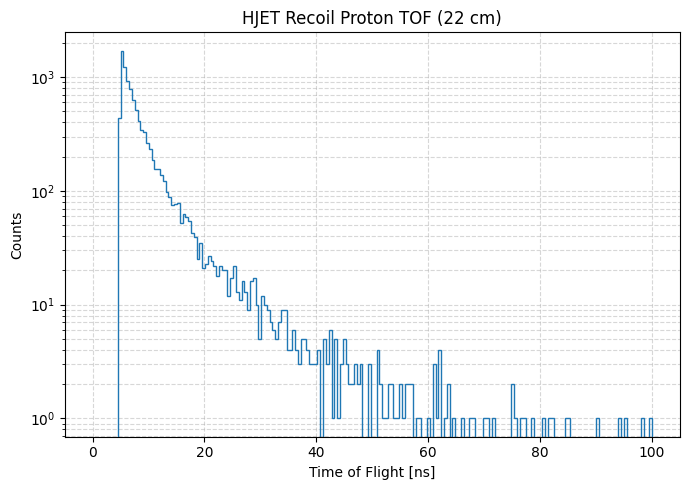

In [4]:
# ---- Histogram ----
bins = np.linspace(0, 100, 200)   # ns

plt.figure(figsize=(7,5))
plt.hist(tof_ns, bins=bins, histtype="step", log=True)

plt.xlabel("Time of Flight [ns]")
plt.ylabel("Counts")
plt.title("HJET Recoil Proton TOF (22 cm)")

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Calculating A<sub>N</sub>

In [5]:
# A_N(t)calculation
def A_N_model(t):
    # A_N calculation for H elastic scattering in CNI region
    G=1.7928
    alpha = 1/137.03
    mb_to_GeV = 2.568 #GeV**-2
    # Hidrogen (p)
    Z = 1
    sig_tot = 35 * mb_to_GeV #mb

    t0=8*math.pi*alpha*Z/sig_tot

    A_N=G*t0*t*np.sqrt(t) / (mp*(t**2+t0**2)) 

    # weight for polarized beam    
    return A_N


Set CM with t < 0.1 GeV^2

In [6]:
A_N = A_N_model(t)
selection = (t < 0.03000 ) & ( t > 0.001)
selection_1 = (t >= 0.1) & (t<1)
selection_2 = (t >= 1) & (t<1e3)

## Lab-frame plots

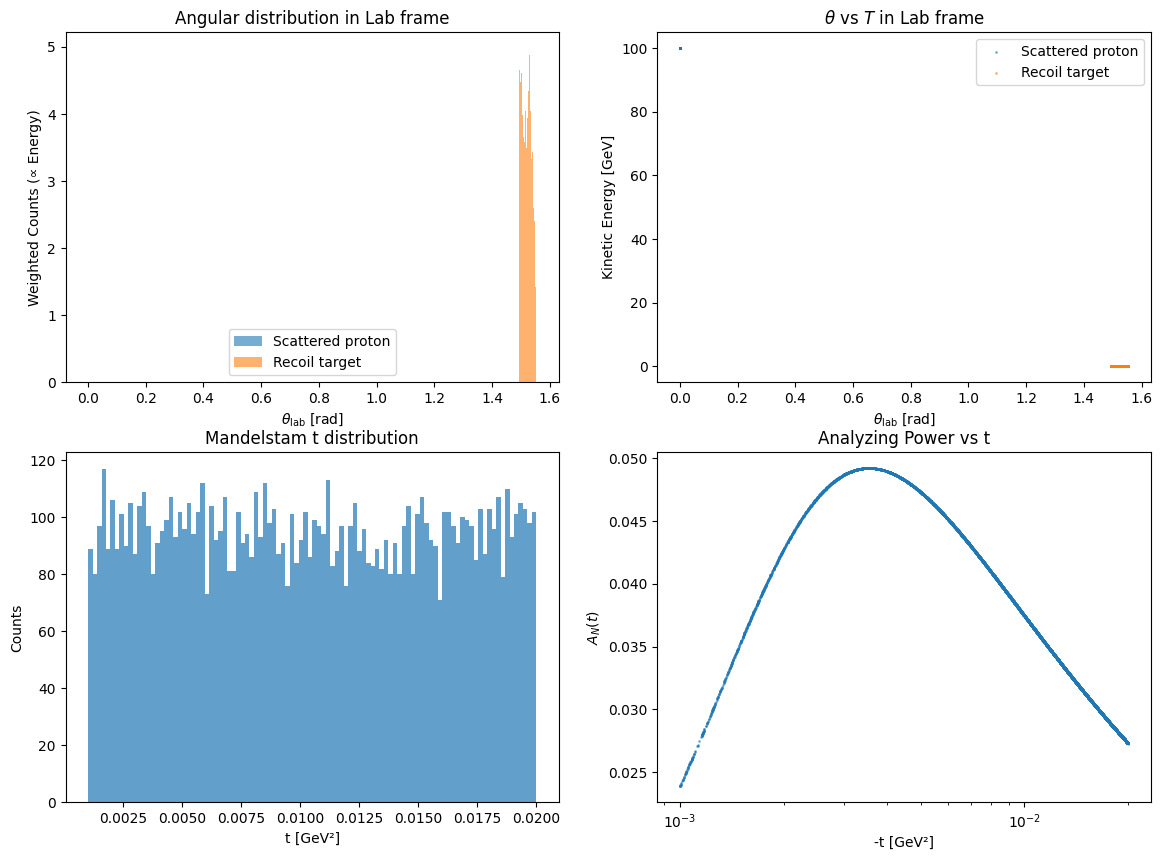

In [7]:
# --- PLOTS ---

import matplotlib.pyplot as plt

# Create first figure: LAB frame plots
fig1, axs1 = plt.subplots(2, 2, figsize=(14, 10))


# 1. Angular distribution (lab)
axs1[0, 0].hist(theta1_lab[selection], bins=100, weights=A_N[selection], alpha=0.6, label='Scattered proton')
axs1[0, 0].hist(theta2_lab[selection], bins=100, weights=A_N[selection], alpha=0.6, label='Recoil target')
axs1[0, 0].set_xlabel(r'$\theta_{\mathrm{lab}}$ [rad]')
axs1[0, 0].set_ylabel('Weighted Counts (∝ Energy)')
axs1[0, 0].set_title('Angular distribution in Lab frame')
axs1[0, 0].legend()

# 2. Energy vs angle
axs1[0, 1].scatter(theta1_lab[selection], T1_lab_final[selection], s=1, alpha=0.5, label='Scattered proton')
axs1[0, 1].scatter(theta2_lab[selection], T2_lab_final[selection], s=1, alpha=0.5, label='Recoil target')
axs1[0, 1].set_xlabel(r'$\theta_{\mathrm{lab}}$ [rad]')
axs1[0, 1].set_ylabel('Kinetic Energy [GeV]')
axs1[0, 1].set_title(r'$\theta$ vs $T$ in Lab frame')
axs1[0, 1].legend()

# 3. Mandelstam t
axs1[1, 0].hist(t[selection], bins=100, alpha=0.7)
axs1[1, 0].set_xlabel('t [GeV²]')
axs1[1, 0].set_ylabel('Counts')
axs1[1, 0].set_title('Mandelstam t distribution')

# 4. A_N(t)
axs1[1, 1].scatter(t[selection], A_N[selection], s=1, alpha=0.5)
axs1[1, 1].set_xlabel('-t [GeV²]')
axs1[1, 1].set_ylabel(r'$A_N(t)$')
axs1[1, 1].set_title('Analyzing Power vs t')
#axs1[1, 1].set_xlim(1e-4, 0.1)
axs1[1, 1].set_xscale('log')

#fig1.tight_layout()
fig1.savefig("lab_frame_plots.png")
plt.show()




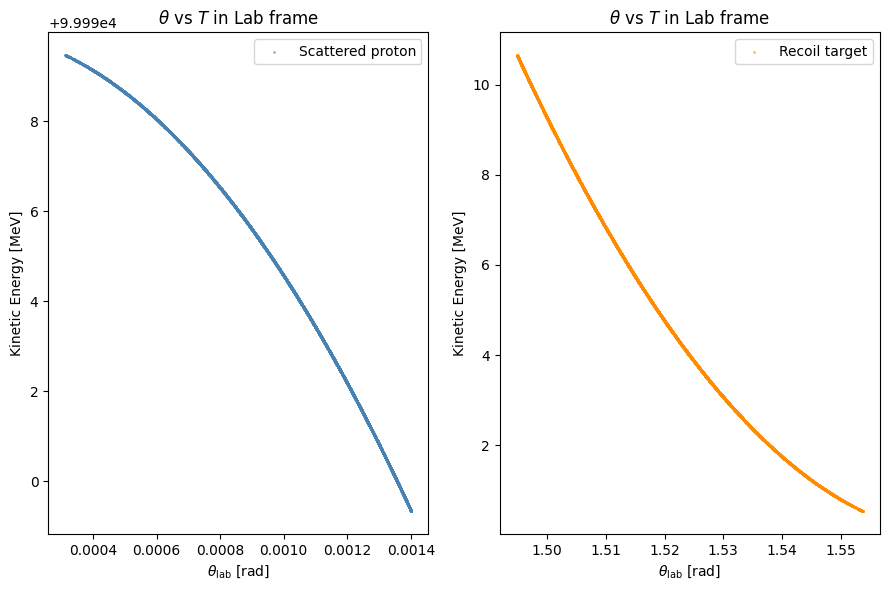

In [8]:
# --- Lab Frame Plots ---
fig, ax = plt.subplots(1, 2, figsize=(9, 6))

ax[0].scatter(theta1_lab[selection], T1_lab_final[selection]*1000, s=1, alpha=0.5, label='Scattered proton', color='steelblue')
ax[0].set_xlabel(r'$\theta_{\mathrm{lab}}$ [rad]')
ax[0].set_ylabel('Kinetic Energy [MeV]')
ax[0].set_title(r'$\theta$ vs $T$ in Lab frame')
ax[0].legend()

ax[1].scatter(theta2_lab[selection], T2_lab_final[selection]*1000, s=1, alpha=0.5, label='Recoil target', color='darkorange')
ax[1].set_xlabel(r'$\theta_{\mathrm{lab}}$ [rad]')
ax[1].set_ylabel('Kinetic Energy [MeV]')
ax[1].set_title(r'$\theta$ vs $T$ in Lab frame')
ax[1].legend()


fig.tight_layout()
fig.savefig("cm_theta_plots.png")
plt.show()


## CM Frame Plots 

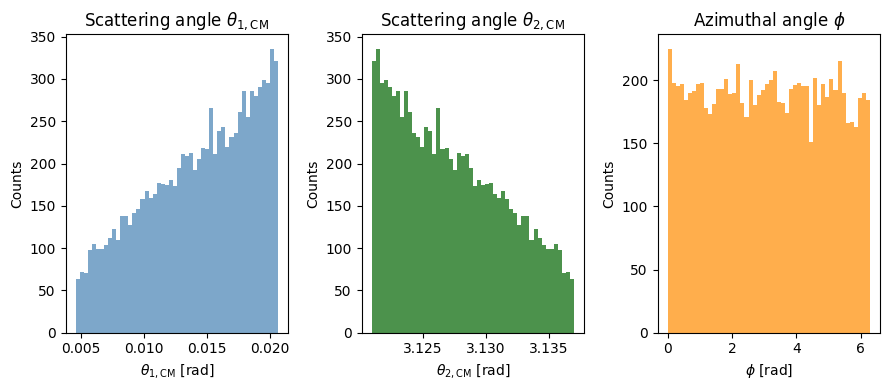

In [9]:
# --- CM Frame Plots ---
fig2, axs2 = plt.subplots(1, 3, figsize=(9, 4))

# 5. θ_cm1 distribution
axs2[0].hist(theta_cm1[selection], bins=50, alpha=0.7, color='steelblue')
axs2[0].set_xlabel(r'$\theta_{1,\mathrm{CM}}$ [rad]')
axs2[0].set_ylabel('Counts')
axs2[0].set_title(r'Scattering angle $\theta_{1,\mathrm{CM}}$')

# 6. θ_cm2 distribution (π - θ1_cm)
axs2[1].hist(theta_cm2[selection], bins=50, alpha=0.7, color='darkgreen')
axs2[1].set_xlabel(r'$\theta_{2,\mathrm{CM}}$ [rad]')
axs2[1].set_ylabel('Counts')
axs2[1].set_title(r'Scattering angle $\theta_{2,\mathrm{CM}}$')

# 7. φ distribution
axs2[2].hist(phi[selection], bins=50, alpha=0.7, color='darkorange')
axs2[2].set_xlabel(r'$\phi$ [rad]')
axs2[2].set_ylabel('Counts')
axs2[2].set_title(r'Azimuthal angle $\phi$')

fig2.tight_layout()
fig2.savefig("cm_frame_plots.png")
plt.show()




In [10]:
x_plane = x[selection]
y_plane = y[selection]
z_plane = z[selection]

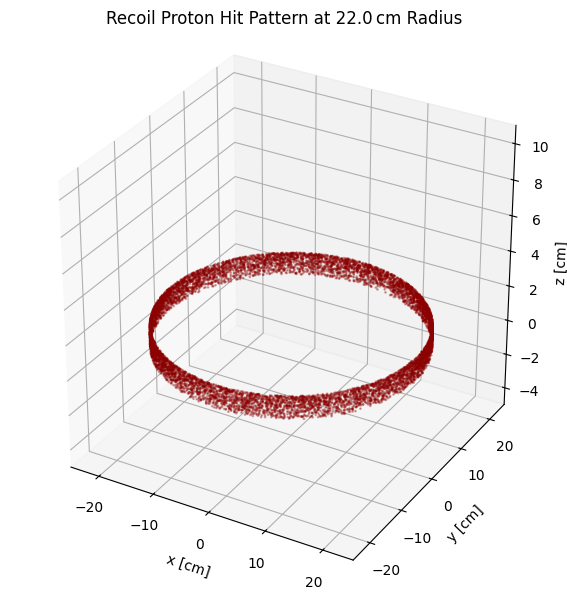

In [11]:
# --- Create 3D plot ---
fig1 = plt.figure(figsize=(8, 6))
axs1 = fig1.add_subplot(111, projection='3d')

axs1.set_zlim(-5, 11)
axs1.scatter(x_plane, y_plane, z_plane, s=1, alpha=0.3, color='darkred')
axs1.set_xlabel("x [cm]")
axs1.set_ylabel("y [cm]")
axs1.set_zlabel("z [cm]")
axs1.set_title(f"Recoil Proton Hit Pattern at {R} cm Radius")
axs1.set_box_aspect([1,1,1])  # Equal aspect ratio

fig1.tight_layout()
fig1.savefig("recoil_proton_3D_hits.png")
plt.show()

In [12]:
def boris_push(r, v, dt, use_B=True):
    q = 1.602e-19     # C
    m = 1.6726e-27    # kg

    if not use_B:
        return r + v*dt, v

    B = get_B(r)     # Tesla
    t = (q * dt / (2 * m)) * B
    t_mag2 = np.dot(t, t)
    s = 2 * t / (1 + t_mag2)

    v_minus = v
    v_prime = v_minus + np.cross(v_minus, t)
    v_plus  = v_minus + np.cross(v_prime, s)

    r_new = r + v_plus * dt
    return r_new, v_plus

def simulate_proton_trajectory_boris(
    r0, v0,
    dt,
    max_steps=N_steps,
    stop_radius=0.22,
    use_B=True
):
    r = r0.copy()
    v = v0.copy()
    trajectory = [r.copy()]

    for _ in range(max_steps):
        if np.linalg.norm(r) >= stop_radius:
            break

        r, v = boris_push(r, v, dt, use_B)
        trajectory.append(r.copy())

    return (np.array(trajectory[-2:]), len(trajectory))  # Return last two points in trajectory and number of steps


## Geometry of the silicon detector

HJET recoil detectors are effectively planar silicon strips perpendicular to the recoil direction.

Let's define:

- Distance from IP to detector plane R
- Two silicon layers:

In [13]:
si_thickness = 300e-4  # cm (300 µm)
gap = 0.0              # cm (can add later if needed)


Energy loss model (Bethe–Bloch, simplified)

For CNI recoil protons:

- T ≈ 100 keV – few MeV

- Silicon stopping power is large and rapidly varying

You do NOT want full Bethe–Bloch here — use tabulated PSTAR-style fit.

A very good approximation in this energy range is:

𝑑𝐸/𝑑𝑥≈𝑎⋅𝛽^(−2)


or even simpler: interpolate a stopping power table.

Minimal practical solution (recommended)

Hard-code a small table and interpolate:
[text](https://physics.nist.gov/PhysRefData/Star/Text/PSTAR.html)

Plot saved as 'pstar_stopping_power_silicon.png'


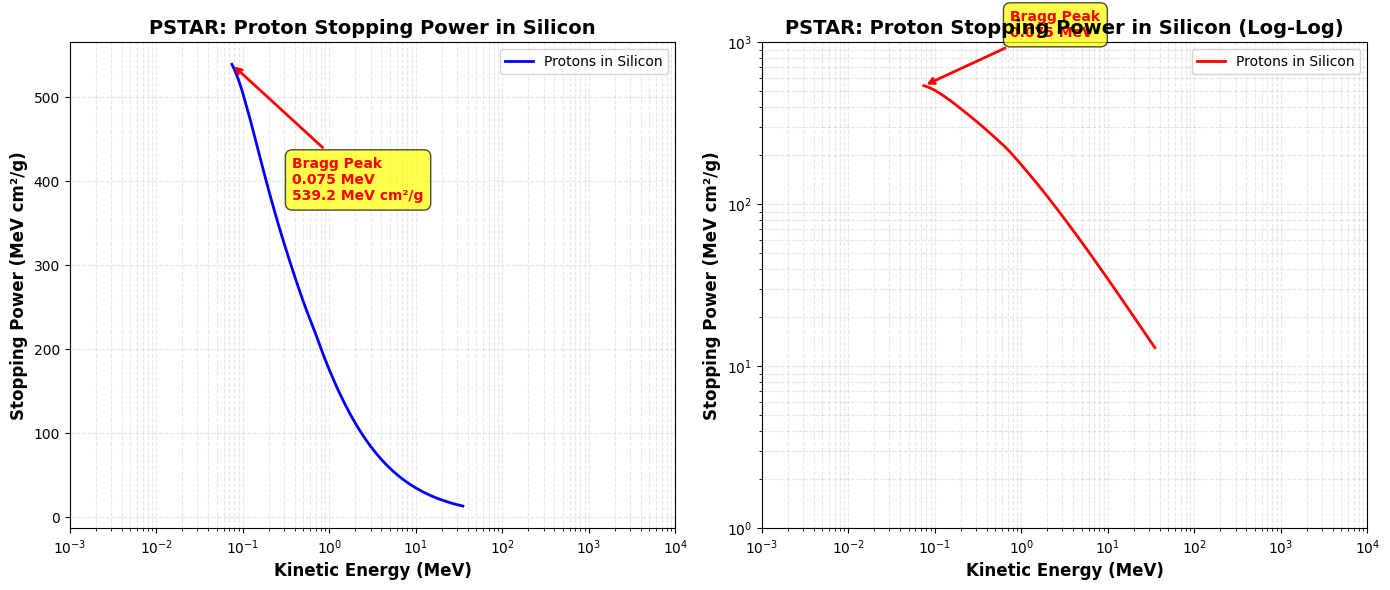


PSTAR Stopping Power Statistics for Protons in Silicon
Energy range: 7.5000e-02 - 3.5000e+01 MeV
Bragg peak location: 0.0750 MeV
Maximum stopping power: 539.20 MeV cm²/g
Minimum stopping power: 13.0200 MeV cm²/g at 35.0 MeV
Number of data points: 58


In [14]:
# PSTAR: Stopping Powers and Range Tables for Protons in SILICON
# Data format: Kinetic Energy (MeV), Total Stopping Power (MeV cm²/g)

data = """
1.000E-03 1.169E+02 
1.500E-03 1.393E+02 
2.000E-03 1.583E+02 
2.500E-03 1.750E+02 
3.000E-03 1.903E+02 
4.000E-03 2.174E+02 
5.000E-03 2.414E+02 
6.000E-03 2.633E+02 
7.000E-03 2.834E+02 
8.000E-03 3.022E+02 
9.000E-03 3.199E+02 
1.000E-02 3.366E+02 
1.250E-02 3.686E+02 
1.500E-02 3.961E+02 
1.750E-02 4.199E+02 
2.000E-02 4.408E+02 
2.250E-02 4.591E+02 
2.500E-02 4.751E+02 
2.750E-02 4.890E+02 
3.000E-02 5.011E+02 
3.500E-02 5.204E+02 
4.000E-02 5.342E+02 
4.500E-02 5.433E+02 
5.000E-02 5.485E+02 
5.500E-02 5.507E+02 
6.000E-02 5.504E+02 
6.500E-02 5.480E+02 
7.000E-02 5.442E+02 
7.500E-02 5.392E+02 
8.000E-02 5.333E+02 
8.500E-02 5.267E+02 
9.000E-02 5.198E+02 
9.500E-02 5.126E+02 
1.000E-01 5.053E+02 
1.250E-01 4.695E+02 
1.500E-01 4.379E+02 
1.750E-01 4.113E+02 
2.000E-01 3.889E+02 
2.250E-01 3.699E+02 
2.500E-01 3.535E+02 
2.750E-01 3.391E+02 
3.000E-01 3.263E+02 
3.500E-01 3.045E+02 
4.000E-01 2.862E+02 
4.500E-01 2.706E+02 
5.000E-01 2.569E+02 
5.500E-01 2.454E+02 
6.000E-01 2.353E+02 
6.500E-01 2.261E+02 
7.000E-01 2.174E+02 
7.500E-01 2.091E+02 
8.000E-01 2.012E+02 
8.500E-01 1.938E+02 
9.000E-01 1.872E+02 
9.500E-01 1.811E+02 
1.000E+00 1.754E+02 
1.250E+00 1.524E+02 
1.500E+00 1.355E+02 
1.750E+00 1.223E+02 
2.000E+00 1.118E+02 
2.250E+00 1.031E+02 
2.500E+00 9.586E+01 
2.750E+00 8.968E+01 
3.000E+00 8.433E+01 
3.500E+00 7.554E+01 
4.000E+00 6.860E+01 
4.500E+00 6.296E+01 
5.000E+00 5.828E+01 
5.500E+00 5.431E+01 
6.000E+00 5.091E+01 
6.500E+00 4.795E+01 
7.000E+00 4.536E+01 
7.500E+00 4.306E+01 
8.000E+00 4.101E+01 
8.500E+00 3.916E+01 
9.000E+00 3.750E+01 
9.500E+00 3.598E+01 
1.000E+01 3.459E+01 
1.250E+01 2.913E+01 
1.500E+01 2.529E+01 
1.750E+01 2.243E+01 
2.000E+01 2.020E+01 
2.500E+01 1.695E+01 
2.750E+01 1.573E+01 
3.000E+01 1.469E+01 
3.500E+01 1.302E+01 
4.000E+01 1.173E+01 
4.500E+01 1.070E+01 
5.000E+01 9.856E+00 
5.500E+01 9.157E+00 
6.000E+01 8.564E+00 
6.500E+01 8.056E+00 
7.000E+01 7.614E+00 
7.500E+01 7.227E+00 
8.000E+01 6.885E+00 
8.500E+01 6.581E+00 
9.000E+01 6.308E+00 
9.500E+01 6.061E+00 
1.000E+02 5.838E+00 
1.250E+02 4.974E+00 
1.500E+02 4.383E+00 
1.750E+02 3.954E+00 
2.000E+02 3.628E+00 
2.250E+02 3.371E+00 
2.500E+02 3.165E+00 
2.750E+02 2.995E+00 
3.000E+02 2.853E+00 
3.500E+02 2.630E+00 
4.000E+02 2.462E+00 
4.500E+02 2.333E+00 
5.000E+02 2.230E+00 
5.500E+02 2.147E+00 
6.000E+02 2.079E+00 
6.500E+02 2.022E+00 
7.000E+02 1.975E+00 
7.500E+02 1.934E+00 
8.000E+02 1.899E+00 
8.500E+02 1.870E+00 
9.000E+02 1.844E+00 
9.500E+02 1.821E+00 
1.000E+03 1.801E+00 
1.500E+03 1.696E+00 
2.000E+03 1.666E+00 
2.500E+03 1.661E+00 
3.000E+03 1.668E+00 
4.000E+03 1.692E+00 
5.000E+03 1.720E+00 
6.000E+03 1.746E+00 
7.000E+03 1.770E+00 
8.000E+03 1.792E+00 
9.000E+03 1.812E+00 
1.000E+04 1.830E+00
"""

# Parse the data
lines = [line.strip() for line in data.strip().split('\n')]
energy = []
stopping_power = []

for line in lines:
    parts = line.split()
    energy.append(float(parts[0]))
    stopping_power.append(float(parts[1]))

energy = np.array(energy)
stopping_power = np.array(stopping_power)

# Selecting certain range 
mask = (energy > 7e-2) & (energy < 4e1)
energy = energy[mask]  # MeV
stopping_power = stopping_power[mask]  # MeV cm²/g


# Create the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Linear-log plot
ax1.plot(energy, stopping_power, 'b-', linewidth=2, label='Protons in Silicon')
ax1.set_xscale('log')
ax1.set_xlabel('Kinetic Energy (MeV)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Stopping Power (MeV cm²/g)', fontsize=12, fontweight='bold')
ax1.set_title('PSTAR: Proton Stopping Power in Silicon', fontsize=14, fontweight='bold')
ax1.grid(True, which='both', alpha=0.3, linestyle='--')
ax1.legend(fontsize=10)
ax1.set_xlim(1e-3, 1e4)

# Log-log plot
ax2.plot(energy, stopping_power, 'r-', linewidth=2, label='Protons in Silicon')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Kinetic Energy (MeV)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Stopping Power (MeV cm²/g)', fontsize=12, fontweight='bold')
ax2.set_title('PSTAR: Proton Stopping Power in Silicon (Log-Log)', fontsize=14, fontweight='bold')
ax2.grid(True, which='both', alpha=0.3, linestyle='--')
ax2.legend(fontsize=10)
ax2.set_xlim(1e-3, 1e4)
ax2.set_ylim(1, 1e3)

# Add Bragg peak annotation
peak_idx = np.argmax(stopping_power)
ax1.annotate(f'Bragg Peak\n{energy[peak_idx]:.3f} MeV\n{stopping_power[peak_idx]:.1f} MeV cm²/g',
             xy=(energy[peak_idx], stopping_power[peak_idx]),
             xytext=(energy[peak_idx]*5, stopping_power[peak_idx]*0.7),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=10, color='red', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

ax2.annotate(f'Bragg Peak\n{energy[peak_idx]:.3f} MeV',
             xy=(energy[peak_idx], stopping_power[peak_idx]),
             xytext=(energy[peak_idx]*10, stopping_power[peak_idx]*2),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=10, color='red', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('pstar_stopping_power_silicon.png', dpi=300, bbox_inches='tight')
print("Plot saved as 'pstar_stopping_power_silicon.png'")
plt.show()

# Print some statistics
print("\n" + "="*60)
print("PSTAR Stopping Power Statistics for Protons in Silicon")
print("="*60)
print(f"Energy range: {energy.min():.4e} - {energy.max():.4e} MeV")
print(f"Bragg peak location: {energy[peak_idx]:.4f} MeV")
print(f"Maximum stopping power: {stopping_power[peak_idx]:.2f} MeV cm²/g")
print(f"Minimum stopping power: {stopping_power.min():.4f} MeV cm²/g at {energy[np.argmin(stopping_power)]:.1f} MeV")
print(f"Number of data points: {len(energy)}")
print("="*60)

In [15]:
# Proton stopping power in silicon (MeV cm^2 / g)
# Rough PSTAR values
#T_table = np.array([0.1, 0.2, 0.5, 1, 2, 5, 10])  # MeV
T_table = np.array(energy)
#dEdx_table = np.array([1200, 800, 400, 250, 150, 70, 40])  # MeV cm^2 / g
dEdx_table = np.array(stopping_power)
rho_Si = 2.33  # g/cm^3

from scipy.interpolate import interp1d
dEdx_interp = interp1d(T_table, dEdx_table,
                       bounds_error=False,
                       fill_value="extrapolate")

In [16]:



from scipy.interpolate import RegularGridInterpolator

#fieldMapFileName = 'FieldMap_BX_tgt_orientation'
#fieldMapFileName = 'FieldMap_BY_tgt_orientation'
#fieldMapFileName = 'FieldMap_BZ_tgt_orientation'
use_B_flag = True
#fieldMapFileName = "Bfield_map_Bx_Pair" 
#fieldMapFileName = "Bfield_map_By_Pair"
#fieldMapFileName = "Bfield_map_Bz_Pair"
configurations = { ("Bfield_map_Bx_Pair", False),
                   ("Bfield_map_Bx_Pair", True),
                   ("Bfield_map_By_Pair", True),
                   ("Bfield_map_Bz_Pair", True) }
for fieldMapFileName, use_B_flag in configurations:
    # Load CSV with magnetic field map
    #
    #   x_mm  y_mm  z_mm      Bx_T      By_T      Bz_T    Bmag_T
    #0  -250  -250  -250 -0.000248  0.001612  0.001612  0.002293
    df_B = pd.read_csv(f"Bfield_map/{fieldMapFileName}.csv")
    print(df_B.head())
    # Extract as NumPy arrays
    x_B = df_B['x_mm'].values
    y_B = df_B['y_mm'].values
    z_B = df_B['z_mm'].values
    Bx = df_B['Bx_T'].values
    By = df_B['By_T'].values
    Bz = df_B['Bz_T'].values




    # Assumes grid is structured in mm, convert to m for interpolation
    xg = np.unique(x_B/1000)
    yg = np.unique(y_B/1000)
    zg = np.unique(z_B/1000)
    
    print(f"Field bounds:")
    print(f"x: [{xg.min():.3f}, {xg.max():.3f}] m")
    print(f"y: [{yg.min():.3f}, {yg.max():.3f}] m")
    print(f"z: [{zg.min():.3f}, {zg.max():.3f}] m")
    
    # Reshape to 3D grid
    Bx_grid = Bx.reshape(len(xg), len(yg), len(zg))
    By_grid = By.reshape(len(xg), len(yg), len(zg))
    Bz_grid = Bz.reshape(len(xg), len(yg), len(zg))
    
    # Create interpolators
    Bx_interp = RegularGridInterpolator((xg, yg, zg), Bx_grid)
    By_interp = RegularGridInterpolator((xg, yg, zg), By_grid)
    Bz_interp = RegularGridInterpolator((xg, yg, zg), Bz_grid)
    
    # Function to get B at a point
    def get_B(r):
        try:
            #r_mag = np.linalg.norm(r)
            #if r_mag < R_cutoff:
            #    return np.array([0.0, 0.0, 0.0])
            #else:
            return np.array([
                Bx_interp(r),
                By_interp(r),
                Bz_interp(r)
            ]).flatten()
        except ValueError as e:
            #print(f"OUT OF BOUNDS: r = {r}")
            return np.array([0.0, 0.0, 0.0])
            #raise


    def simulate_proton_trajectory(r0, v0, dt=1e-11, steps=10000, use_B=True, stop_radius=0.22):
        q = 1.602e-19      # C
        m = 1.6726e-27     # kg (proton mass)
        v0 = v0 # m/s
        
        r = np.array(r0, dtype=float)
        v = np.array(v0, dtype=float)
    
        trajectory = [r.copy()]
        for _ in range(steps):
        
            # Stop if out of bounds
            r_mag = np.linalg.norm(r)
            if r_mag >= stop_radius:
                break
            
            B = get_B(r) if use_B else np.zeros(3)
            a = q / m * np.cross(v, B)
            v += a * dt
            r += v * dt
            trajectory.append(r.copy())
            
        return np.array(trajectory[-2:]), len(trajectory)  # Return last two points in trajectory and number of steps
    
    
    

    
    # Initial direction from theta2_lab and phi2_lab
    #speed_c = 1  # cm/ns (adjust based on T2_lab_final)
    #speed = beta * c # cm/ns → m/ns

    from mpl_toolkits.mplot3d import Axes3D
    
    
    #end_x = []
    #end_y = []
    #end_z = []
    
    # Plot 3D trajectory
    #fig = plt.figure()
    #ax = fig.add_subplot(111, projection='3d')
    
    results = []
    #i=0
    
    sigma_beam = (1.0/3.0) /100  # m
    x0 = np.random.normal(0, sigma_beam, n_events)
    y0 = np.random.normal(0, sigma_beam, n_events)
    z0 = np.random.normal(0, sigma_beam, n_events)

    for i, (Theta2_lab, Phi2_lab, T1_lab_i, T2_lab_i, t_i, A_N_i, Speed) in enumerate(zip(theta2_lab[selection],phi2_lab[selection], T1_lab_final[selection], T2_lab_final[selection],t[selection], A_N[selection], speed[selection])):
        #Speed = Speed * 1e-2 * 1e9  # cm/ns → m/s
        v0 = Speed * 1e-2 * 1e9 * np.array([
            np.sin(Theta2_lab) * np.cos(Phi2_lab),
            np.sin(Theta2_lab) * np.sin(Phi2_lab),
            np.cos(Theta2_lab)
        ])
        #v0 = speed_c * np.array([
        #    np.sin(Theta2_lab) * np.cos(Phi2_lab),
        #    np.sin(Theta2_lab) * np.sin(Phi2_lab),
        #    np.cos(Theta2_lab)
        #])        
        #r0 = np.array([0.0, 0.0, 0.0])  # starting at origin
        r0 = np.array([x0[i], y0[i], z0[i]])  # m
        # R in meters for trajectory simulation
        trajectory, t_shape = simulate_proton_trajectory(r0, v0, dt=time_step, steps=N_steps, use_B=use_B_flag  , stop_radius=R/100) # NO B FOR RIGHT NOW FOR FASTER WORK
        #trajectory, t_shape = simulate_proton_trajectory_boris(r0, v0, time_step, use_B=use_B_flag, stop_radius=R/100)
        #trajectory_noB   = simulate_proton_trajectory(r0, v0, use_B=False , stop_radius=R/100)
        #len_trajectory_noB = len(trajectory_noB)
        #print(f"Trajectory length with B: {len_trajectory}, without B: {len_trajectory_noB}")
        # Final positions
        r1 = trajectory[-2]
        r = trajectory[-1]
        tof_ns = t_shape * time_step * 1e9  # convert s to ns
        #tof_ns = (R / np.sin(Theta2_lab)) / (Speed)  # cm/ns

        end_x = r[0]*100
        end_y = r[1]*100
        end_z = r[2]*100
        #print(f"Event {i}: Final position with B: x1={r1[0]:.2f} cm, x={end_x:.2f} cm, y1={r1[1]:.2f} cm, y={end_y:.2f} cm, z1={r1[2]*100:.2f} cm, z={end_z:.2f} cm, TOF={tof_ns:.2f} ns, t_shape={t_shape}, TOF shape={tof_ns_shape:.2f} ns, Velocity={Speed:.2f} cm/ns")
        #get track direction at detector
        n_hat = r / np.linalg.norm(r)

        dr = trajectory[-1] - trajectory[-2]
        v_hat = dr / np.linalg.norm(dr)
        cos_incidence = abs(np.dot(v_hat, n_hat))

        path_length_si = si_thickness / cos_incidence
        
        # ### Two-layer energy deposition with energy degradation
        # 
        # Important:
        # Energy entering layer 2 is reduced by layer 1 loss
        T2_lab_i = T2_lab_i * 1000  # GeV → MeV
        dEdx = dEdx_interp(T2_lab_i) * rho_Si
        # Layer 1
        dE1 = min(dEdx * path_length_si, T2_lab_i)
        T_after_1 = T2_lab_i - dE1
        # Layer 2
        dEdx_2 = dEdx_interp(max(T_after_1, 0.01)) * rho_Si
        dE2 = min(dEdx_2 * path_length_si, T_after_1)
        T_after_2 = T_after_1 - dE2
                
        results.append({
            'T1_lab': T1_lab_i,
            'T2_lab': T2_lab_i,
            't': t_i,
    
            'p_x_cm':   r[0]*100 ,
            'p_y_cm':   r[1]*100 ,
            'p_z_cm':   r[2]*100 ,
            'tof_ns':  tof_ns,
            'A_N':    A_N_i,
            'theta2_lab': Theta2_lab, 
            'phi2_lab': Phi2_lab,
            'Si_E1_MeV': dE1,
            'Si_E2_MeV': dE2,
            'T_exit_MeV': T_after_2
        })   
        #i+=1 
        #print(f"Δx = {delta[0]*100:.2f} cm, Δy = {delta[1]*100:.2f} cm, Δz = {delta[2]*100:.2f} cm")
        #ax.plot(trajectory[:,0]*100, trajectory[:,1]*100, trajectory[:,2]*100)  # m → cm
    #ax.set_xlabel('x [cm]')
    #ax.set_ylabel('y [cm]')
    #ax.set_zlabel('z [cm]')
    #ax.set_title('Proton trajectory in magnetic field')
    #plt.show()
    #for i in range(len(delta_end_x)):
    print(results[0])
    # Create DataFrame
    df = pd.DataFrame(results)
    
    # Save to CSV
    if use_B_flag:
        fileName = f"proton_drift_comparison_Vertex_1cm_withB_{fieldMapFileName}_R{R}.csv"
    else:
        fileName = f"proton_drift_comparison_Vertex_1cm_noB_R{R}.csv"
    df.to_csv(fileName, index=False)
    print(f"Saved to {fileName}")
    
    

   x_mm  y_mm  z_mm      Bx_T      By_T      Bz_T    Bmag_T
0  -250  -250  -250  0.000792  0.000792 -0.000004  0.001119
1  -250  -245  -250  0.000802  0.000818  0.000006  0.001146
2  -250  -240  -250  0.000812  0.000846  0.000017  0.001173
3  -250  -235  -250  0.000822  0.000874  0.000029  0.001200
4  -250  -230  -250  0.000831  0.000903  0.000041  0.001228
Field bounds:
x: [-0.250, 0.250] m
y: [-0.250, 0.250] m
z: [-0.250, 0.250] m
{'T1_lab': np.float64(99.99490484290429), 'T2_lab': np.float64(5.095157096125513), 't': np.float64(0.009558514711994981), 'p_x_cm': np.float64(17.800546720194845), 'p_y_cm': np.float64(-12.934731146563339), 'p_z_cm': np.float64(0.45997678292056027), 'tof_ns': 6.909999999999999, 'A_N': np.float64(0.03815391451774132), 'theta2_lab': np.float64(1.5182419022029505), 'phi2_lab': np.float64(-0.5475744543292193), 'Si_E1_MeV': np.float64(4.021786044407563), 'Si_E2_MeV': np.float64(1.0733710517179507), 'T_exit_MeV': np.float64(0.0)}
Saved to proton_drift_comparison_

/var/folders/6m/3j6qvgsd3lxgmv5gsl7n4sbm0000gp/T/ipykernel_23983/436759340.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


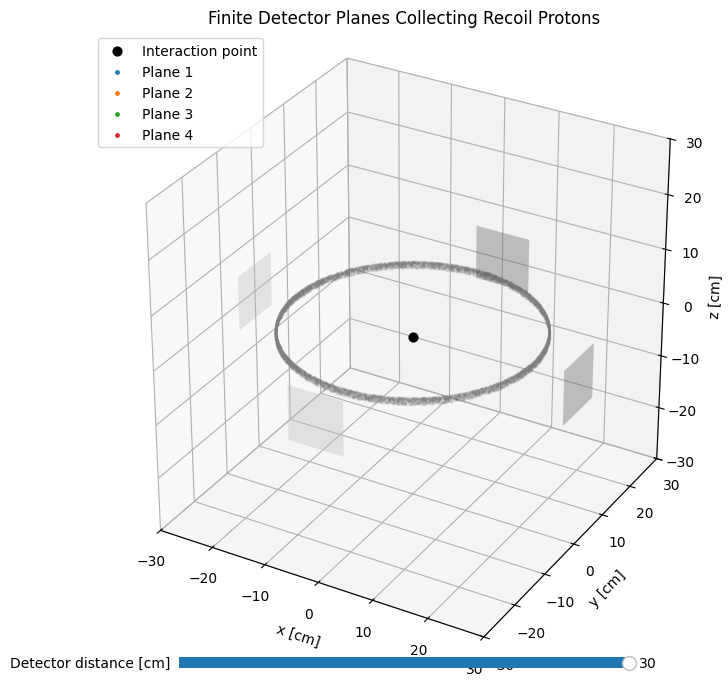

In [17]:
from matplotlib.widgets import Slider


# ---------------- Detector configuration ----------------
angles = np.deg2rad([0, 90, 180, 270])
plane_width  = 10.0   # cm
plane_height = 10.0   # cm
plane_tol    = 0.3  # thickness

collected = [np.zeros(len(x_plane), dtype=bool) for _ in range(4)]


# ---------------- Figure ----------------
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim(-30, 30)
ax.set_ylim(-30, 30)
ax.set_zlim(-30, 30)
ax.set_box_aspect([1,1,1])

ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_zlabel("z [cm]")
ax.set_title("Finite Detector Planes Collecting Recoil Protons")

# Origin
ax.scatter(0, 0, 0, s=40, c='black', label="Interaction point")

# All particles (faint)
ax.scatter(x_plane, y_plane, z_plane, s=1, alpha=0.1, color='gray')

# Collected hit scatters
hit_scatters = [
    ax.scatter([], [], [], s=6, label=f"Plane {i+1}")
    for i in range(4)
]

# Plane surfaces
plane_surfaces = []

def draw_plane(theta, d):
    n = np.array([np.cos(theta), np.sin(theta), 0])
    u = np.array([-np.sin(theta), np.cos(theta), 0])
    v = np.array([0, 0, 1])

    center = d * n

    uu = np.linspace(-plane_width/2, plane_width/2, 2)
    vv = np.linspace(-plane_height/2, plane_height/2, 2)
    U, V = np.meshgrid(uu, vv)

    X = center[0] + U*u[0] + V*v[0]
    Y = center[1] + U*u[1] + V*v[1]
    Z = center[2] + U*u[2] + V*v[2]

    return X, Y, Z

# ---------------- Slider ----------------
ax_d = plt.axes([0.25, 0.03, 0.5, 0.03])
s_d = Slider(ax_d, "Detector distance [cm]", 5, 30.0, valinit=30.0)

# ---------------- Update ----------------
def update(val):
    global plane_surfaces
    d = s_d.val

    # remove old planes
    for surf in plane_surfaces:
        surf.remove()
    plane_surfaces = []

    for i, theta in enumerate(angles):
        n = np.array([np.cos(theta), np.sin(theta), 0])
        u = np.array([-np.sin(theta), np.cos(theta), 0])

        # distance to plane
        dist = (x_plane*n[0] + y_plane*n[1]) - d

        # intersection condition
        hit_plane = np.abs(dist) < plane_tol

        # in-plane coordinates
        proj_u = x_plane*u[0] + y_plane*u[1]
        proj_v = z_plane

        in_box = (
            np.abs(proj_u) < plane_width/2
        ) & (
            proj_v < plane_height/2
        ) & (
            proj_v > -plane_height/2
        )

        newly_collected = hit_plane & in_box & (~collected[i])
        collected[i] |= newly_collected

        hit_scatters[i]._offsets3d = (
            x_plane[collected[i]],
            y_plane[collected[i]],
            z_plane[collected[i]]
        )

        # draw plane
        Xp, Yp, Zp = draw_plane(theta, d)
        surf = ax.plot_surface(
            Xp, Yp, Zp,
            color='lightgray',
            alpha=0.35,
            linewidth=0
        )
        plane_surfaces.append(surf)

    fig.canvas.draw_idle()

s_d.on_changed(update)
update(None)

ax.legend(loc="upper left")
plt.tight_layout()
plt.show()



# Analysis

In [18]:
df_full = pd.read_csv(f"proton_drift_comparison_Vertex_1cm_noB_R{R}.csv")  # Replace with actual filename
df_BX_full = pd.read_csv(f"proton_drift_comparison_Vertex_1cm_withB_Bfield_map_Bx_Pair_R{R}.csv")  # Replace with actual filename
df_BY_full = pd.read_csv(f"proton_drift_comparison_Vertex_1cm_withB_Bfield_map_By_Pair_R{R}.csv")  # Replace with actual filename
df_BZ_full = pd.read_csv(f"proton_drift_comparison_Vertex_1cm_withB_Bfield_map_Bz_Pair_R{R}.csv")  # Replace with actual filename

print(df_full.head()) 
print(df_BX_full.head())
print(df_BY_full.head())
print(df_BZ_full.head())

      T1_lab     T2_lab         t     p_x_cm     p_y_cm    p_z_cm  tof_ns  \
0  99.994905   5.095157  0.009559  18.892200 -11.237850  1.183724    7.13   
1  99.994605   5.395027  0.010121  11.779918 -18.590286  0.567858    6.93   
2  99.998192   1.808366  0.003392   8.642651  20.228569  0.643773   11.78   
3  99.994358   5.641695  0.010584  -5.484510  21.303221  0.705320    6.77   
4  99.989586  10.414178  0.019537   8.040889  20.386637  2.268354    5.00   

        A_N  theta2_lab  phi2_lab  Si_E1_MeV  Si_E2_MeV  T_exit_MeV  
0  0.038154    1.518242 -0.547574   4.021203   1.073954    0.000000  
1  0.037254    1.516720 -0.990273   3.856547   1.538480    0.000000  
2  0.049171    1.539469  1.144878   1.808366   0.000000    0.000000  
3  0.036553    1.515500  1.841665   3.730590   1.911105    0.000000  
4  0.027603    1.495731  1.176239   2.355956   2.853169    5.205053  
      T1_lab     T2_lab         t     p_x_cm     p_y_cm    p_z_cm  tof_ns  \
0  99.994905   5.095157  0.009559  18.86

In [19]:
import numpy as np

# Convert target angles from degrees to radians
#target_angles_deg = [0,  45, 135, 180, 225, 315]
target_angles_deg = [0,  180]
target_angles_rad = np.deg2rad(target_angles_deg)

# Angular tolerance: 5 cm arc on 22 cm radius circle
tolerance_rad = 5 / 22  # approximately 0.227 radians

# Function to find minimum angular distance (accounting for wraparound at ±π)
#def min_angular_distance(angle, targets):
#    distances = []
#    test_angle = angle
#    if test_angle < 0:
#        test_angle += 2 * np.pi
#    for target in targets:
#        # Calculate difference and normalize to [-π, π]
#        diff = np.abs(test_angle - target)
#        distances.append(diff)
#    return np.min(distances)
def min_angular_distance(angle, targets):
    distances = []
    for target in targets:
        # Calculate difference and normalize to [-π, π]
        diff = angle - target
        diff = np.arctan2(np.sin(diff), np.cos(diff))  # Normalize to [-π, π]
        distances.append(np.abs(diff))
    return np.min(distances)

# Calculate phi from p_x_cm and p_y_cm using arctan2
df_full['phi_end'] = np.arctan2(df_full['p_y_cm'], df_full ['p_x_cm'])
df_BX_full['phi_end'] = np.arctan2(df_BX_full['p_y_cm'], df_BX_full['p_x_cm'])
df_BY_full['phi_end'] = np.arctan2(df_BY_full['p_y_cm'], df_BY_full['p_x_cm'])
df_BZ_full['phi_end'] = np.arctan2(df_BZ_full['p_y_cm'], df_BZ_full['p_x_cm'])

# Apply filter
mask = df_full['phi_end'].apply(lambda x: min_angular_distance(x, target_angles_rad) <= tolerance_rad)
mask_BX = df_BX_full['phi_end'].apply(lambda x: min_angular_distance(x, target_angles_rad) <= tolerance_rad)
mask_BY = df_BY_full['phi_end'].apply(lambda x: min_angular_distance(x, target_angles_rad) <= tolerance_rad)
mask_BZ = df_BZ_full['phi_end'].apply(lambda x: min_angular_distance(x, target_angles_rad) <= tolerance_rad)

df = df_full[mask]
df_BX = df_BX_full[mask_BX]
df_BY = df_BY_full[mask_BY]
df_BZ = df_BZ_full[mask_BZ]

In [20]:


tof_ns_noB = df['tof_ns'].values
tof_ns_withBX = df_BX['tof_ns'].values
tof_ns_withBY = df_BY['tof_ns'].values
tof_ns_withBZ = df_BZ['tof_ns'].values

Si_E1_MeV_noB = df['Si_E1_MeV'].values
Si_E1_MeV_withBX = df_BX['Si_E1_MeV'].values
Si_E1_MeV_withBY = df_BY['Si_E1_MeV'].values
Si_E1_MeV_withBZ = df_BZ['Si_E1_MeV'].values

Si_E2_MeV_noB = df['Si_E2_MeV'].values
Si_E2_MeV_withBX = df_BX['Si_E2_MeV'].values
Si_E2_MeV_withBY = df_BY['Si_E2_MeV'].values
Si_E2_MeV_withBZ = df_BZ['Si_E2_MeV'].values

T_exit_MeV_noB = df['T_exit_MeV'].values
T_exit_MeV_withBX = df_BX['T_exit_MeV'].values
T_exit_MeV_withBY = df_BY['T_exit_MeV'].values
T_exit_MeV_withBZ = df_BZ['T_exit_MeV'].values


t_noB = df['t'].values
t_withBX = df_BX['t'].values
t_withBY = df_BY['t'].values
t_withBZ = df_BZ['t'].values

T_noB = df['T2_lab'].values
T_withBX = df_BX['T2_lab'].values
T_withBY = df_BY['T2_lab'].values
T_withBZ = df_BZ['T2_lab'].values

# Position with magnetic field
x_withB = df_BX['p_x_cm'].values
y_withB = df_BX['p_y_cm'].values
z_withB = df_BX['p_z_cm'].values
A_N_withB = df_BX['A_N'].values

x_withBY = df_BY['p_x_cm'].values
y_withBY = df_BY['p_y_cm'].values
z_withBY = df_BY['p_z_cm'].values
A_N_withBY = df_BY['A_N'].values

x_withBZ = df_BZ['p_x_cm'].values
y_withBZ = df_BZ['p_y_cm'].values
z_withBZ = df_BZ['p_z_cm'].values
A_N_withBZ = df_BZ['A_N'].values

# Position without magnetic field
x_noB = df['p_x_cm'].values
y_noB = df['p_y_cm'].values
z_noB = df['p_z_cm'].values
A_N_noB = df['A_N'].values

T2_lab = df['T2_lab'].values
theta2_lab = df['theta2_lab'].values
A_N = df['A_N'].values


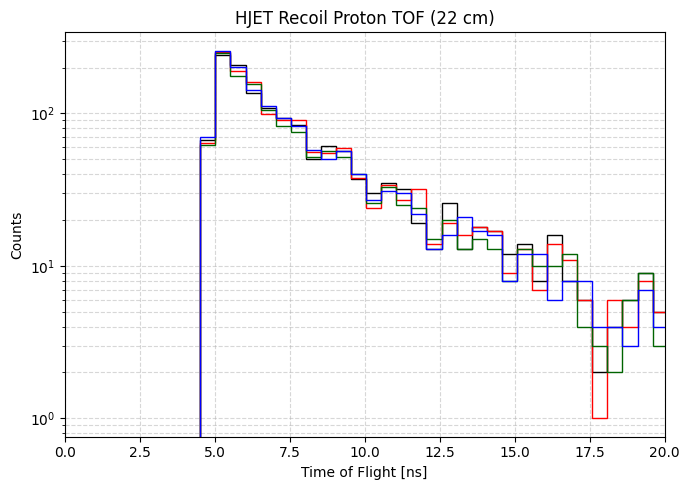

In [21]:
# ---- Histogram ----
bins = np.linspace(0, 100, 200)   # ns

plt.figure(figsize=(7,5))
plt.hist(tof_ns_noB,    bins=bins, histtype="step", label='No B-field',    color="black",     log=True)
plt.hist(tof_ns_withBX, bins=bins, histtype="step", label='With BX-field', color="red",       log=True)
plt.hist(tof_ns_withBY, bins=bins, histtype="step", label='With BY-field', color="darkgreen", log=True)
plt.hist(tof_ns_withBZ, bins=bins, histtype="step", label='With BZ-field', color="blue",      log=True)






plt.xlabel("Time of Flight [ns]")
plt.ylabel("Counts")
plt.title("HJET Recoil Proton TOF (22 cm)")

plt.xlim(0, 20)

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

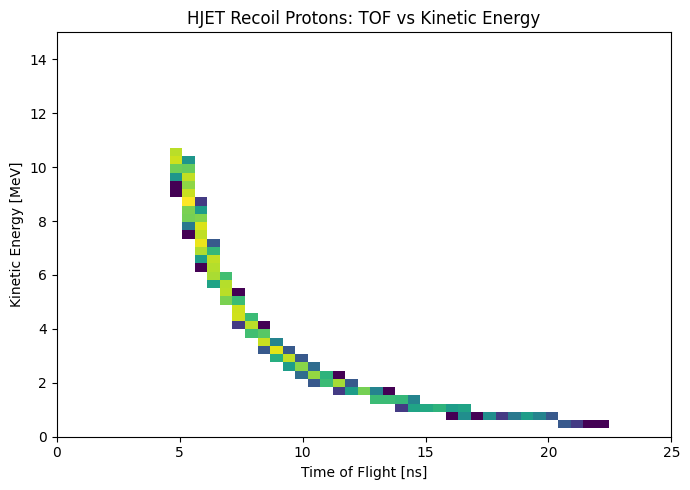

In [22]:
import numpy as np
# ---- 2D Histogram Bins ----
tof_bins = np.linspace(0, 25, 50)     # ns
T_bins   = np.linspace(0, 15, 50)      # MeV (HJET recoil range)

# ---- 2D histogram ----
H, xedges, yedges = np.histogram2d(
    tof_ns_noB,
    T_noB,  # Convert GeV to MeV
    bins=[tof_bins, T_bins]
)
#print(sorted(tof_ns_noB)[:10])
# ---- Plot ----
plt.figure(figsize=(7,5))

plt.pcolormesh(
    xedges,
    yedges,
    H.T,
    shading="auto",
    norm=plt.matplotlib.colors.LogNorm()
)

plt.xlabel("Time of Flight [ns]")
plt.ylabel("Kinetic Energy [MeV]")
plt.title("HJET Recoil Protons: TOF vs Kinetic Energy")

#cbar = plt.colorbar()
#cbar.set_label("Counts")

plt.grid(False)
plt.tight_layout()
plt.show()


/var/folders/6m/3j6qvgsd3lxgmv5gsl7n4sbm0000gp/T/ipykernel_23983/357673106.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter1 = ax4[0,0].scatter(tof_ns_noB, T_noB ,    cmap='viridis', alpha = 0.7)
/var/folders/6m/3j6qvgsd3lxgmv5gsl7n4sbm0000gp/T/ipykernel_23983/357673106.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter2 = ax4[0,1].scatter(tof_ns_withBX, T_withBX ,    cmap='viridis', alpha = 0.7)
/var/folders/6m/3j6qvgsd3lxgmv5gsl7n4sbm0000gp/T/ipykernel_23983/357673106.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter3 = ax4[1,0].scatter(tof_ns_withBY, T_withBY ,    cmap='viridis', alpha = 0.7)
/var/folders/6m/3j6qvgsd3lxgmv5gsl7n4sbm0000gp/T/ipykernel_23983/357673106.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatte4 = ax4[1,1].scatter(tof_ns_withBZ, T_withBZ ,    

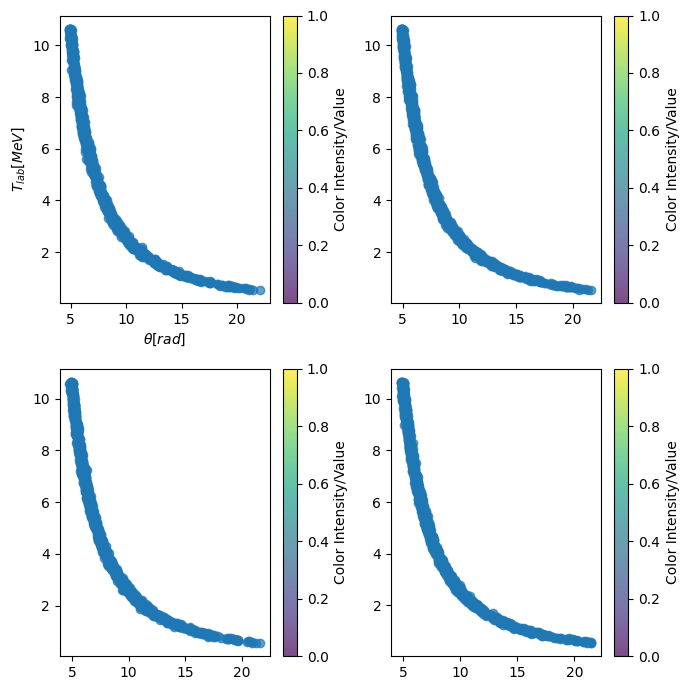

In [23]:
#fig, ax = plt.subplots(figsize=(5, 4))
fig4, ax4 = plt.subplots(2, 2, figsize=(7, 7))

scatter1 = ax4[0,0].scatter(tof_ns_noB, T_noB ,    cmap='viridis', alpha = 0.7)
scatter2 = ax4[0,1].scatter(tof_ns_withBX, T_withBX ,    cmap='viridis', alpha = 0.7)
scatter3 = ax4[1,0].scatter(tof_ns_withBY, T_withBY ,    cmap='viridis', alpha = 0.7)
scatte4 = ax4[1,1].scatter(tof_ns_withBZ, T_withBZ ,    cmap='viridis', alpha = 0.7)

# Add a colorbar for the 'colors' variable
cbar1 = plt.colorbar(scatter1)
cbar2 = plt.colorbar(scatter2)
cbar3 = plt.colorbar(scatter3)
cbar4 = plt.colorbar(scatte4)
cbar1.set_label("Color Intensity/Value")
cbar2.set_label("Color Intensity/Value")
cbar3.set_label("Color Intensity/Value")
cbar4.set_label("Color Intensity/Value")

ax4[0,0].set_xlabel('$\\theta [rad]$')
ax4[0,0].set_ylabel('$T_{lab} [MeV]$')

plt.tight_layout()
plt.show()

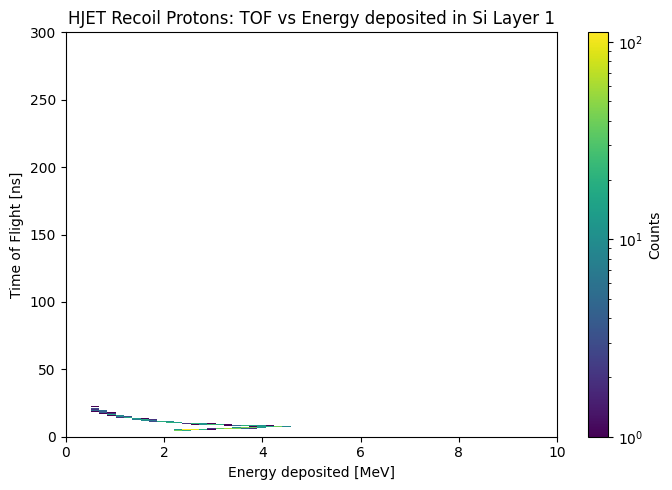

In [24]:
#import numpy as np
# ---- 2D Histogram Bins ----
tof_bins = np.linspace(0, 300, 600)     # ns
Si_E1_bins   = np.linspace(0, 10, 60)      # MeV (HJET recoil range)

# ---- 2D histogram ----
H, xedges, yedges = np.histogram2d(
    Si_E1_MeV_noB,
    tof_ns_noB,  
    bins=[Si_E1_bins, tof_bins]
)

# ---- Plot ----
plt.figure(figsize=(7,5))

plt.pcolormesh(
    xedges,
    yedges,
    H.T,
    shading="auto",
    norm=plt.matplotlib.colors.LogNorm()
)

plt.ylabel("Time of Flight [ns]")
plt.xlabel("Energy deposited [MeV]")
plt.title("HJET Recoil Protons: TOF vs Energy deposited in Si Layer 1")

cbar = plt.colorbar()
cbar.set_label("Counts")

plt.grid(False)
plt.tight_layout()
plt.show()

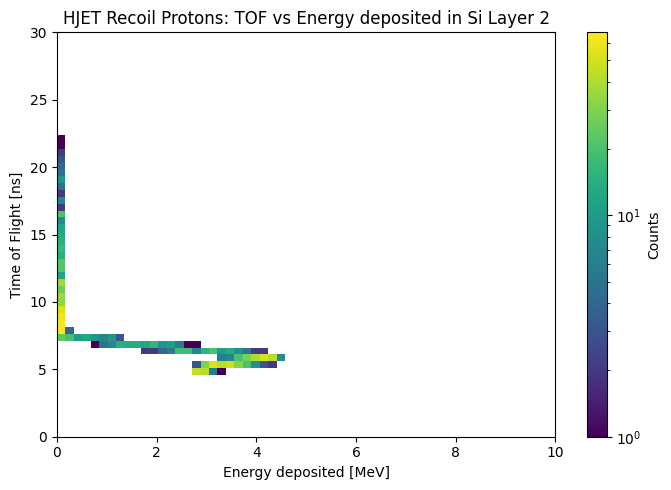

In [25]:
# ---- 2D Histogram Bins ----
tof_bins = np.linspace(0, 30, 60)     # ns
Si_E2_bins   = np.linspace(0, 10, 60)      # MeV (HJET recoil range)

# ---- 2D histogram ----
H, xedges, yedges = np.histogram2d(
    Si_E2_MeV_noB,
    tof_ns_noB,  
    bins=[Si_E2_bins, tof_bins]
)

# ---- Plot ----
plt.figure(figsize=(7,5))

plt.pcolormesh(
    xedges,
    yedges,
    H.T,
    shading="auto",
    norm=plt.matplotlib.colors.LogNorm()
)

plt.ylabel("Time of Flight [ns]")
plt.xlabel("Energy deposited [MeV]")
plt.title("HJET Recoil Protons: TOF vs Energy deposited in Si Layer 2")

cbar = plt.colorbar()
cbar.set_label("Counts")

plt.grid(False)
plt.tight_layout()
plt.show()

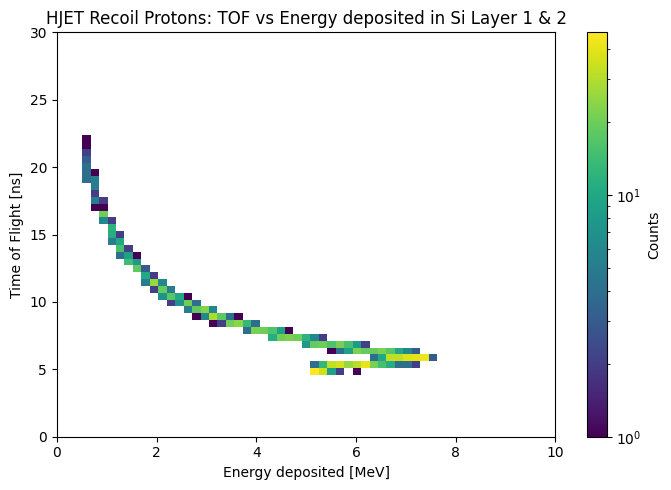

In [26]:

# ---- 2D Histogram Bins ----
tof_bins = np.linspace(0, 30, 60)     # ns
Si_E2_bins   = np.linspace(0, 10, 60)      # MeV (HJET recoil range)

# ---- 2D histogram ----
H, xedges, yedges = np.histogram2d(
    (Si_E2_MeV_noB+Si_E1_MeV_noB),
    tof_ns_noB,  
    bins=[Si_E2_bins, tof_bins]
)

# ---- Plot ----
plt.figure(figsize=(7,5))

plt.pcolormesh(
    xedges,
    yedges,
    H.T,
    shading="auto",
    norm=plt.matplotlib.colors.LogNorm()
)

plt.ylabel("Time of Flight [ns]")
plt.xlabel("Energy deposited [MeV]")
plt.title("HJET Recoil Protons: TOF vs Energy deposited in Si Layer 1 & 2")

cbar = plt.colorbar()
cbar.set_label("Counts")

plt.grid(False)
plt.tight_layout()
plt.show()

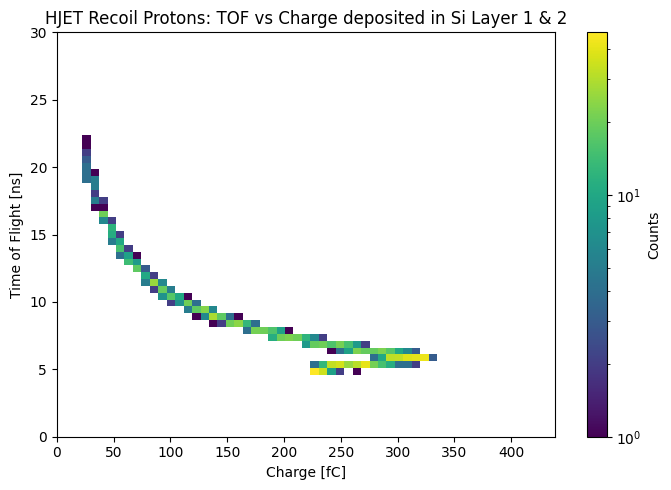

In [27]:
C_SSD = 17 # pC
w = 3.65 # eV
e_per_MeV = 1e6 / w
ch_per_MeV = e_per_MeV * 1.602 * 1e-19  * 1e15# fC per MeV
# ---- 2D Histogram Bins ----
tof_bins = np.linspace(0, 30, 60)     # ns
Si_E2_bins   = np.linspace(0, 10, 60)      # MeV (HJET recoil range)

# ---- 2D histogram ----
H, xedges, yedges = np.histogram2d(
    (Si_E2_MeV_noB+Si_E1_MeV_noB)*ch_per_MeV,
    tof_ns_noB,  
    bins=[Si_E2_bins*ch_per_MeV, tof_bins]
)

# ---- Plot ----
plt.figure(figsize=(7,5))

plt.pcolormesh(
    xedges,
    yedges,
    H.T,
    shading="auto",
    norm=plt.matplotlib.colors.LogNorm()
)

plt.ylabel("Time of Flight [ns]")
plt.xlabel("Charge [fC]")
plt.title("HJET Recoil Protons: TOF vs Charge deposited in Si Layer 1 & 2")

cbar = plt.colorbar()
cbar.set_label("Counts")

plt.grid(False)
plt.tight_layout()
plt.show()

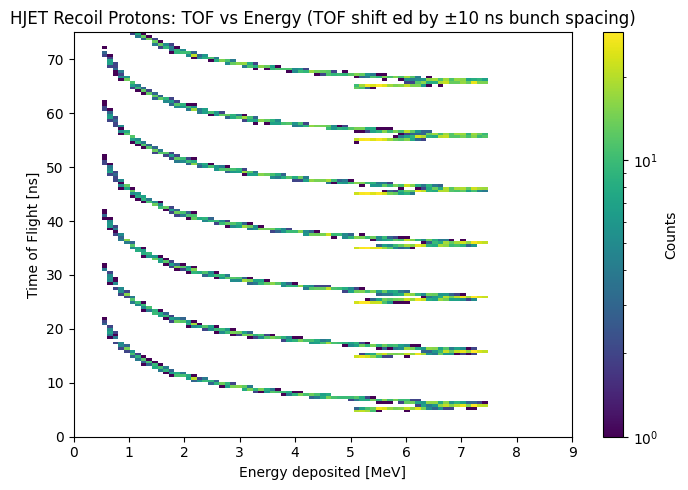

In [28]:
tof_bins = np.linspace(0, 75, 150)     # ns
Si_E2_bins   = np.linspace(0, 9, 90)      # MeV (HJET recoil range)

tof_shifts = [0,  +10, +20, +30, +40, +50, +60]  # ns

plt.figure(figsize=(7,5))

for shift in tof_shifts:
    H, xedges, yedges = np.histogram2d(
        Si_E2_MeV_noB + Si_E1_MeV_noB,
        tof_ns_noB + shift,
        bins=[Si_E2_bins, tof_bins]
    )

    plt.pcolormesh(
        xedges,
        yedges,
        H.T,
        shading="auto",
        norm=plt.matplotlib.colors.LogNorm()
    )

plt.xlabel("Energy deposited [MeV]")
plt.ylabel("Time of Flight [ns]")
plt.title("HJET Recoil Protons: TOF vs Energy (TOF shift ed by ±10 ns bunch spacing)")

cbar = plt.colorbar()
cbar.set_label("Counts")

plt.tight_layout()
plt.show()


/var/folders/6m/3j6qvgsd3lxgmv5gsl7n4sbm0000gp/T/ipykernel_23983/1059144414.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


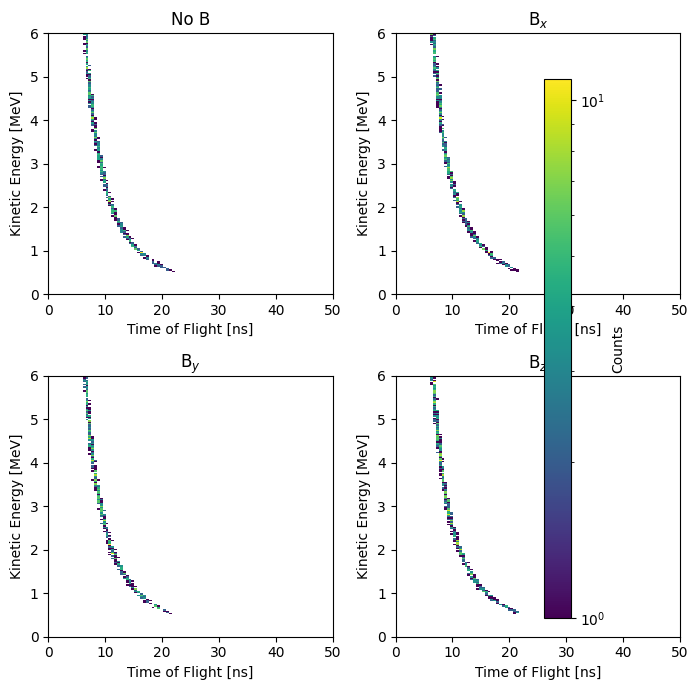

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

fig4, ax4 = plt.subplots(2, 2, figsize=(7, 7))

# ---- Common binning ----
tof_bins = np.linspace(0, 50, 100)   # ns
T_bins   = np.linspace(0, 6, 200)     # MeV

datasets = [
    (tof_ns_noB,   T_noB,   "No B"),
    (tof_ns_withBX, T_withBX , "B$_x$"),
    (tof_ns_withBY, T_withBY , "B$_y$"),
    (tof_ns_withBZ, T_withBZ , "B$_z$")
]

pcm_list = []

for ax, (tof, T, title) in zip(ax4.flat, datasets):

    # 2D histogram
    H, xedges, yedges = np.histogram2d(
        tof,
        T,
        bins=[tof_bins, T_bins]
    )

    # Density plot
    pcm = ax.pcolormesh(
        xedges,
        yedges,
        H.T,
        shading="auto",
        norm=LogNorm(vmin=1)  # avoid log(0)
    )

    ax.set_title(title)
    ax.set_xlabel("Time of Flight [ns]")
    ax.set_ylabel("Kinetic Energy [MeV]")

    pcm_list.append(pcm)

# ---- Single shared colorbar (recommended) ----
cbar = fig4.colorbar(pcm_list[0], ax=ax4.ravel().tolist())
cbar.set_label("Counts")

plt.tight_layout()
plt.show()


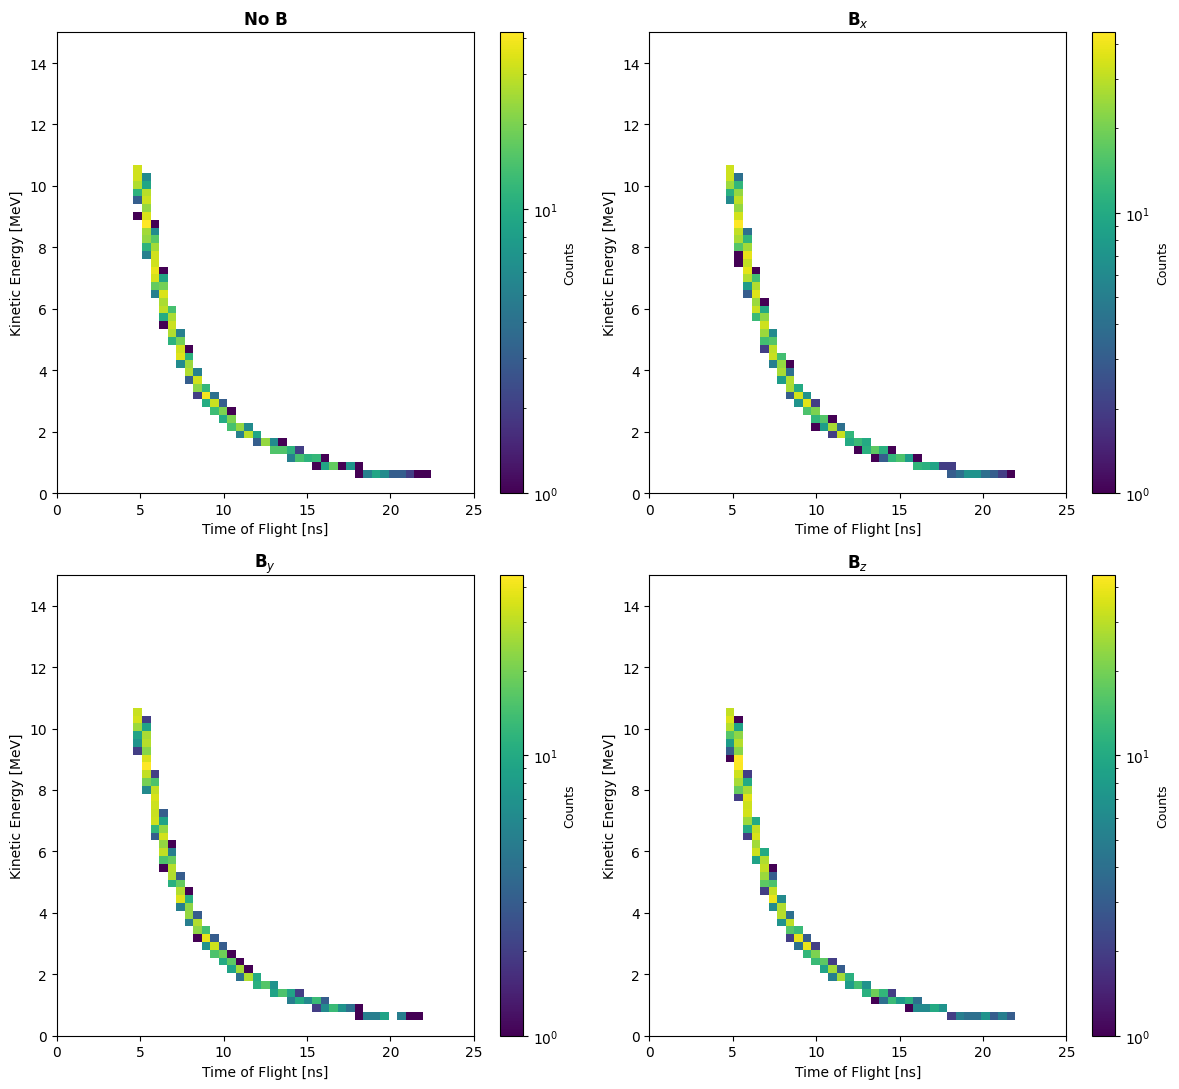

In [30]:
fig4, ax4 = plt.subplots(2, 2, figsize=(12, 11))

# ---- Common binning ----
tof_bins = np.linspace(0, 25, 50)   # ns
T_bins   = np.linspace(0, 15, 60)     # MeV

datasets = [
    (tof_ns_noB,   T_noB,   "No B"),
    (tof_ns_withBX, T_withBX, "B$_x$"),
    (tof_ns_withBY, T_withBY, "B$_y$"),
    (tof_ns_withBZ, T_withBZ, "B$_z$")
]

for ax, (tof, T, title) in zip(ax4.flat, datasets):

    # 2D histogram
    H, xedges, yedges = np.histogram2d(
        tof,
        T,
        bins=[tof_bins, T_bins]
    )

    # Check if histogram has data
    if H.max() > 0:
        # Find min/max of non-zero values
        non_zero = H[H > 0]
        vmin = max(non_zero.min(), 1)  # Ensure vmin >= 1
        vmax = non_zero.max()
        
        # Density plot
        pcm = ax.pcolormesh(
            xedges,
            yedges,
            H.T,
            shading="auto",
            norm=LogNorm(vmin=vmin, vmax=vmax)
        )
        
        # Individual colorbar for this subplot
        cbar = plt.colorbar(pcm, ax=ax)
        cbar.set_label("Counts", fontsize=9)
    else:
        # Empty histogram - just show empty plot
        ax.text(0.5, 0.5, 'No Data', 
                transform=ax.transAxes,
                ha='center', va='center',
                fontsize=16, color='red')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Time of Flight [ns]", fontsize=10)
    ax.set_ylabel("Kinetic Energy [MeV]", fontsize=10)
    ax.set_xlim(0, 25)
    ax.set_ylim(0, 15)

plt.tight_layout()
plt.show()

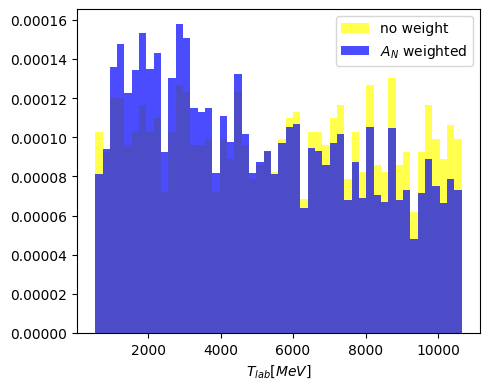

In [31]:
# Sphere parameters
radius = 3  # 3 cm
zoffset = 4  # center offset from origin (so 4 cm between sphere centers)
offset = 5  # center offset from origin (so 4 cm between sphere centers)

# Sphere surface mesh
phi, theta = np.mgrid[0:np.pi:20j, 0:2*np.pi:20j]
x_s = radius * np.sin(phi) * np.cos(theta)
y_s = radius * np.sin(phi) * np.sin(theta)
z_s = radius * np.cos(phi)

# Sphere center positions
centers = [
    ( offset,   offset, zoffset),
    (-offset,  -offset, zoffset),
    ( -offset,  offset, zoffset),
    ( offset,  -offset, zoffset),
    #( offset,   offset, zoffset+7),
    #(-offset,  -offset, zoffset+7),
    #( -offset,  offset, zoffset+7),
    #( offset,  -offset, zoffset+7),
    ( offset,   offset, -zoffset),
    (-offset,  -offset, -zoffset),
    ( -offset,  offset, -zoffset),
    ( offset,  -offset, -zoffset),
    #( offset,   offset, -zoffset-7),
    #(-offset,  -offset, -zoffset-7),
    #( -offset,  offset, -zoffset-7),
    #( offset,  -offset, -zoffset-7)
]

num_bins = 50

fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T2_lab*1000, 
        bins=num_bins, 
        label='no weight',
        density = 1, 
        color ='yellow', 
        alpha = 0.7)
ax.hist(T2_lab*1000, 
        bins=num_bins, 
        weights=A_N,
        label='$A_{N}$ weighted',
        density = 1, 
        color ='blue', 
        alpha = 0.7)
ax.set_xlabel('$T_{lab} [MeV]$')
ax.legend()

plt.tight_layout()
plt.show()


/var/folders/6m/3j6qvgsd3lxgmv5gsl7n4sbm0000gp/T/ipykernel_23983/1724096208.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(theta2_lab,T2_lab*1000,


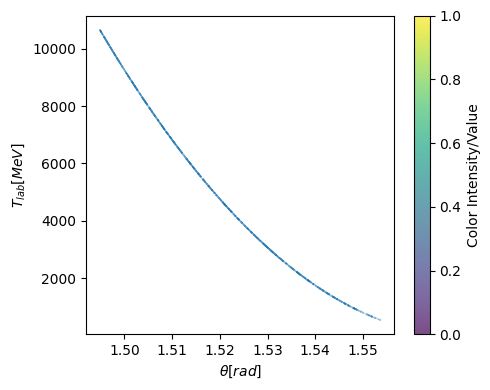

In [32]:
fig, ax = plt.subplots(figsize=(5, 4))

scatter = ax.scatter(theta2_lab,T2_lab*1000, 
        s=A_N, 
        cmap='viridis',
        alpha = 0.7)

# Add a colorbar for the 'colors' variable
cbar = plt.colorbar(scatter)
cbar.set_label("Color Intensity/Value")

ax.set_xlabel('$\\theta [rad]$')
ax.set_ylabel('$T_{lab} [MeV]$')

plt.tight_layout()
plt.show()


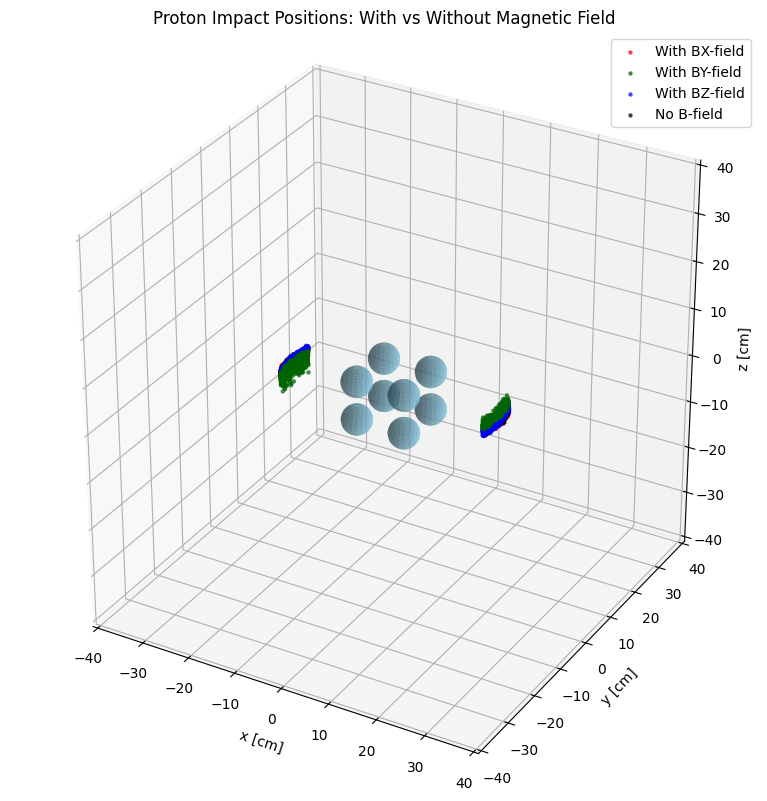

In [33]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw spheres
for cx, cy, cz in centers:
    ax.plot_surface(x_s + cx, y_s + cy, z_s + cz, color='skyblue', alpha=0.6, linewidth=0)

# Plot points with magnetic field
ax.scatter(x_withB, y_withB, z_withB, s=5, c='red', label='With BX-field', alpha=0.6)
ax.scatter(x_withBY, y_withBY, z_withBY, s=5, c='darkgreen', label='With BY-field', alpha=0.6)
ax.scatter(x_withBZ, y_withBZ, z_withBZ, s=5, c='blue', label='With BZ-field', alpha=0.6)

# Plot points without magnetic field
ax.scatter(x_noB, y_noB, z_noB, s=5, c='black', label='No B-field', alpha=0.6)

ax.set_xlabel('x [cm]')
ax.set_ylabel('y [cm]')
ax.set_zlabel('z [cm]')
ax.set_title('Proton Impact Positions: With vs Without Magnetic Field')
ax.legend()
ax.set_box_aspect([1, 1, 1])  # Equal aspect ratio

# Set limits to visualize nicely
lim = 41  # ±6 cm
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

#for i in range(len(x_withB)):
#    ax.plot(
#        [x_noB[i], x_withBY[i]],
#        [y_noB[i], y_withBY[i]],
#        [z_noB[i], z_withBY[i]],
#        color='gray', alpha=0.3, linewidth=0.5
#    )

plt.tight_layout()
plt.show()

# 3D Visualization of HJET Magnet (Python Translation)
This notebook is an automatic translation of `xzy_sketch_3D_det250.m` from MATLAB to Python.

Libraries used:
- numpy
- matplotlib (3D)


In [34]:
#%matplotlib notebook
# For interactive 3D rotation in Jupyter, use:
%matplotlib widget
# (requires: pip install ipympl)

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

## Parameters (translated from MATLAB)

In [35]:

# Parameters
r_det = 220      # detector radius [mm]
r_det_2nd = 225      # detector radius [mm]
detSize = 100    # detector square size [mm]

d = 85           # coil offset (centerline) [mm]
a = 20           # coil cross section side [mm]
L_coil = 66.2    # coil loop side length [mm]
s = 33.1         # half spacing (L_coil/2) [mm]
coilCol = [0, 0, 1]  # blue
coilCol_2nd = [0.7, 0.7, 0.7]  # light gray


# Shades of gray from light to dark
gray_lightest = [0.95, 0.95, 0.95]  # very light gray
gray_lighter = [0.85, 0.85, 0.85]   # lighter gray
gray_light = [0.7, 0.7, 0.7]        # light gray
gray_medium = [0.5, 0.5, 0.5]       # medium gray
gray_dark = [0.3, 0.3, 0.3]         # dark gray
gray_darker = [0.15, 0.15, 0.15]    # darker gray
gray_darkest = [0.05, 0.05, 0.05]   # very dark gray

#detCol = [1, 0, 1]  # magenta
#detCol_2nd = [0.7, 0.7, 0.7]  # light gray

detCol = [0.7, 0.7, 0.7]  # magenta
detCol_2nd = [0.15, 0.15, 0.15]  # light gray



r_circle = 50    # inner circle radius [mm]
oct_R = 100 / np.cos(np.radians(22.5))  # octagon radius

xlimv = 250
ylimv = 250
zlimv = 150

fs1 = 12
fs2 = 14

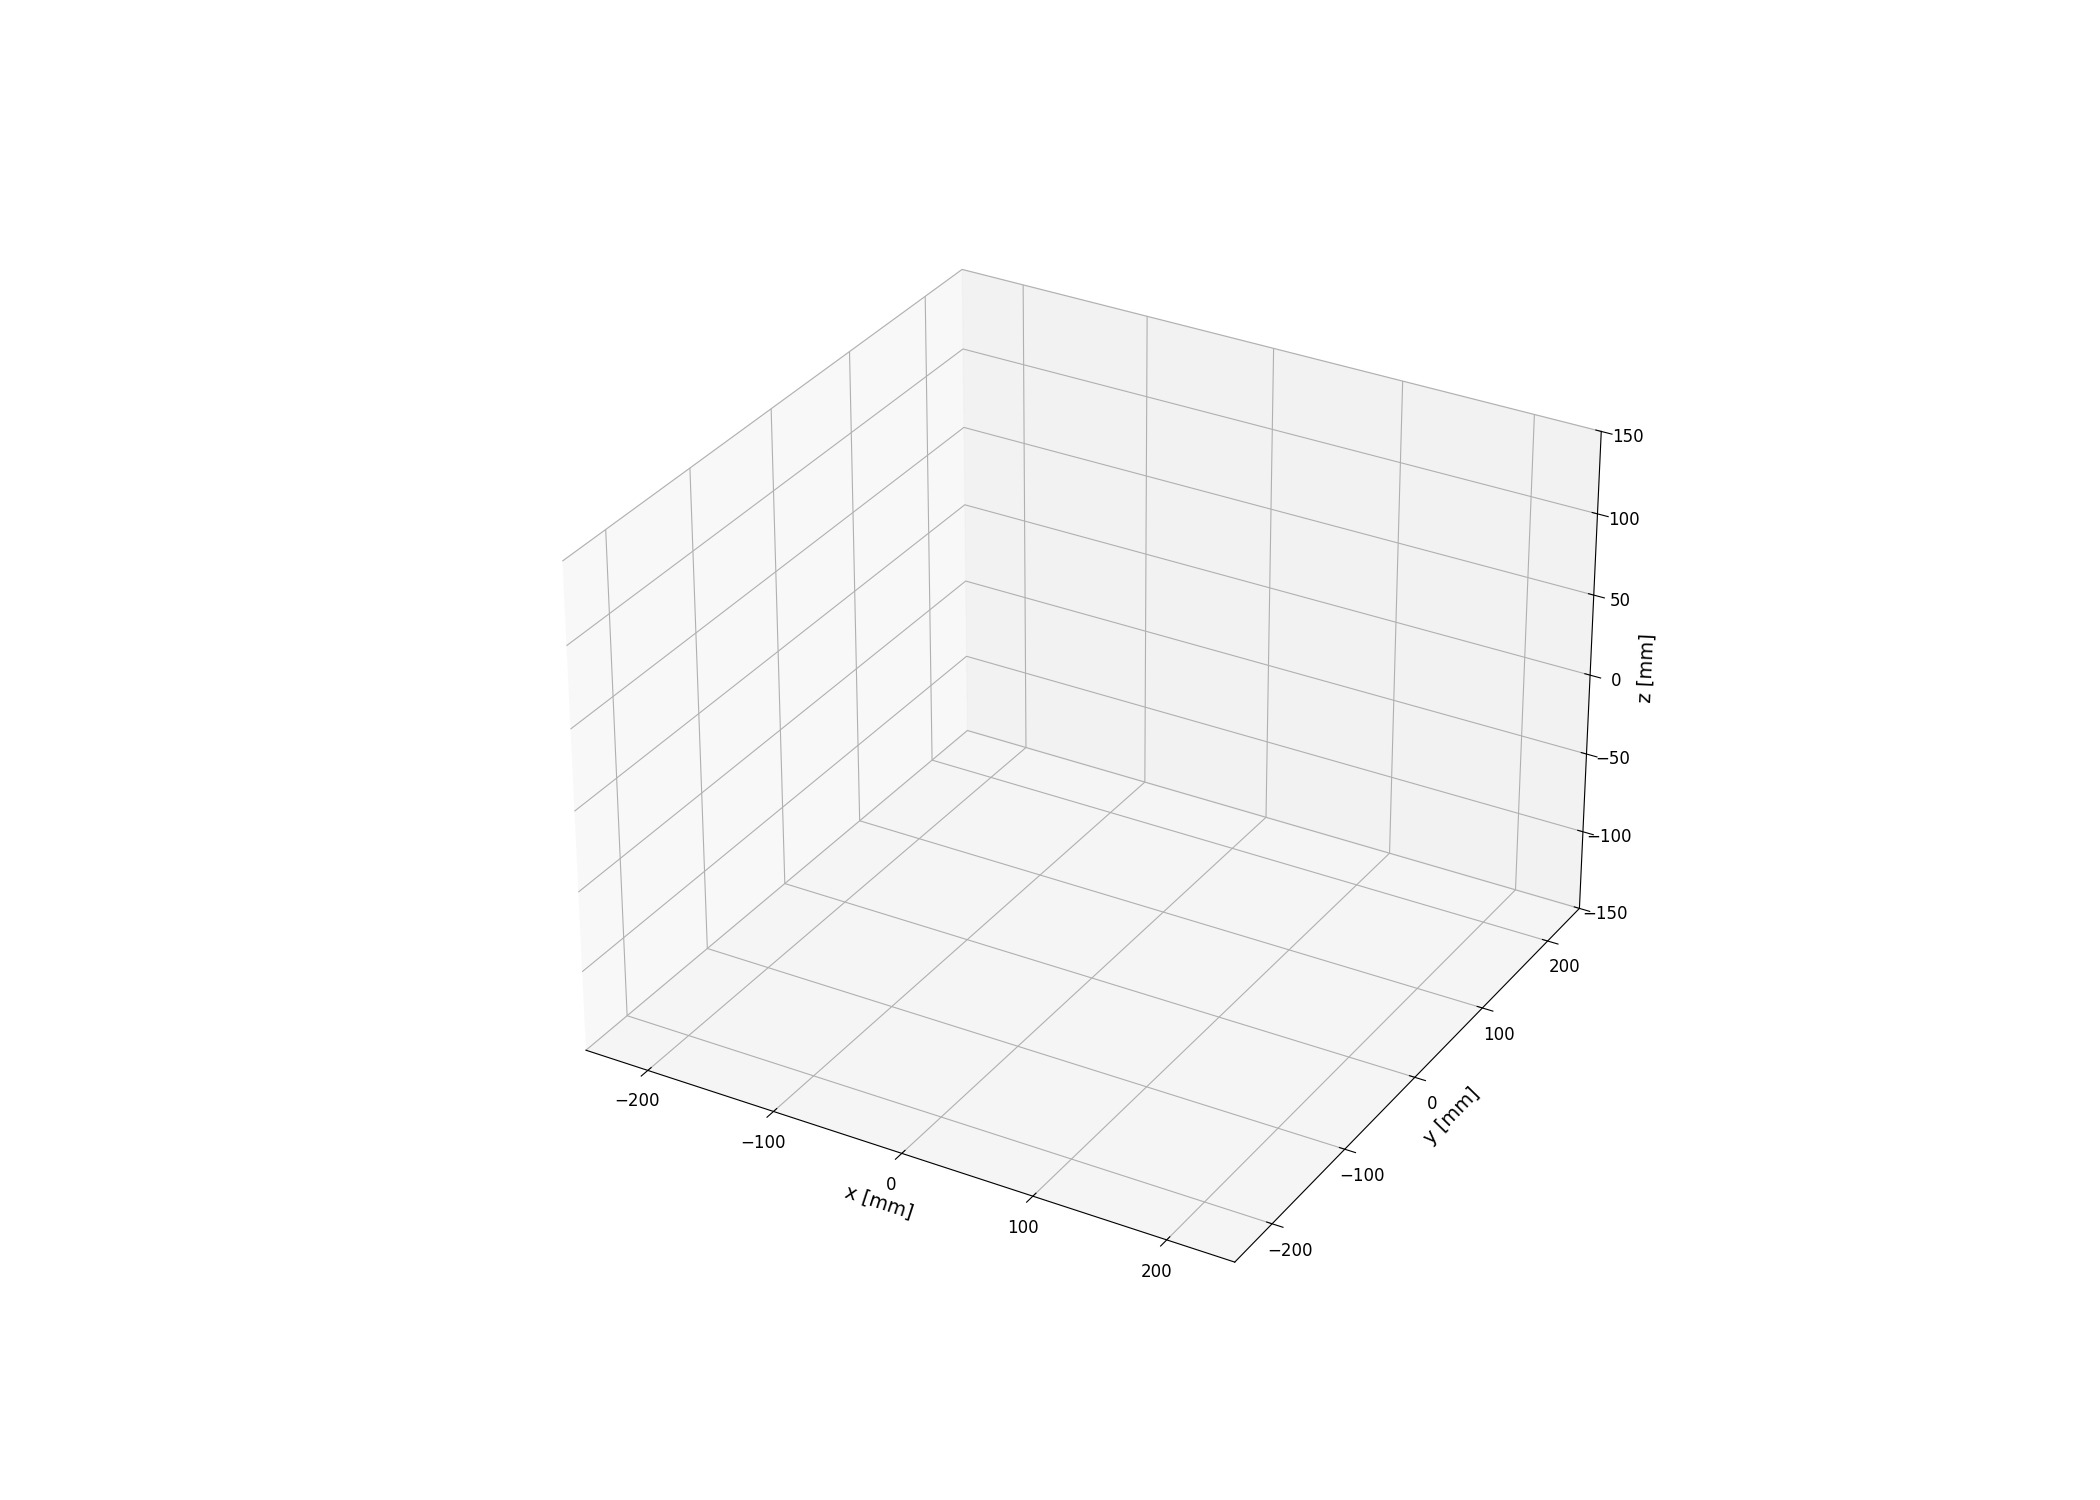

In [36]:


# Create figure and 3D axes
fig = plt.figure(figsize=(14*1.5, 10*1.5), facecolor='w')
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim([-xlimv, xlimv])
ax.set_ylim([-ylimv, ylimv])
ax.set_zlim([-zlimv, zlimv])

ax.set_xlabel('x [mm]', fontsize=fs2)
ax.set_ylabel('y [mm]', fontsize=fs2)
ax.set_zlabel('z [mm]', fontsize=fs2)
ax.tick_params(labelsize=fs1)



## Coordinate axes visualization

In [37]:
set_elev = 40
set_azim = 160
set_roll = -105
ax.scatter(x_noB * 10, y_noB*10, z_noB*10, s=5, c='black', label='No B-field', alpha=0.6)
#ax.scatter(x_withB*10, y_withB*10, z_withB*10, s=5, c='red', label='With B-field', alpha=0.6)

# Plot points with magnetic field
ax.scatter(x_withB * 10, y_withB * 10, z_withB * 10, s=5, c='red', label='With BX-field', alpha=0.6)
ax.scatter(x_withBY * 10, y_withBY * 10, z_withBY * 10, s=5, c='darkgreen', label='With BY-field', alpha=0.6)
ax.scatter(x_withBZ * 10, y_withBZ * 10, z_withBZ * 10, s=5, c='blue', label='With BZ-field', alpha=0.6)

scale = 0.85
ax.quiver(0, 0, 0, xlimv*scale, 0, 0, color='r', arrow_length_ratio=0.07, linewidth=3)
ax.quiver(0, 0, 0, 0, ylimv*scale, 0, color='g', arrow_length_ratio=0.07, linewidth=3)
ax.quiver(0, 0, 0, 0, 0, zlimv*scale, color='b', arrow_length_ratio=0.07, linewidth=3)

ax.text(xlimv*0.90, 0, 0, 'x', fontsize=fs2+20, fontweight='bold', color='r')
ax.text(0, ylimv*0.90, 0, 'y', fontsize=fs2+20, fontweight='bold', color='g')
ax.text(0, 0, zlimv*0.90, 'z', fontsize=fs2+20, fontweight='bold', color='b')

# Inner circle at z=0
t = np.linspace(0, 2*np.pi, 100)
ax.plot(r_circle*np.cos(t), r_circle*np.sin(t), np.zeros_like(t),
        color=[0, 0.45, 0.35], linewidth=2.0)

# Set the viewing angle
ax.view_init(elev=set_elev, azim=set_azim, roll=set_roll)  # elev = elevation, azim = azimuth, roll = roll angle



In [38]:



# 22.5° construction lines in xy-plane at z=0
L = 1.2 * max(xlimv, ylimv)
angles = np.arange(0, 360, 22.5)
dashColor = [0.7, 0.7, 0.7]

for th in angles:
    u = np.array([np.cos(np.radians(th)), np.sin(np.radians(th))])
    p1 = -L * u
    p2 = +L * u
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [0, 0], 
            '--', color=dashColor, linewidth=0.8)
    
# Octagon at z=0
k = np.arange(8)
phi0 = 22.5
x8 = oct_R * np.cos(np.radians(phi0 + 45*k))
y8 = oct_R * np.sin(np.radians(phi0 + 45*k))
x8 = np.append(x8, x8[0])
y8 = np.append(y8, y8[0])
ax.plot(x8, y8, np.zeros_like(x8), '-', color=[1.0, 0.6, 0.0], linewidth=2.0)

## Helper functions

In [39]:

def draw_coil_leg(ax, center, width, height, length, direction, color):
    """Draw a rectangular coil leg"""
    cx, cy, cz = center
    half_len = length / 2
    half_w = width / 2
    half_h = height / 2
    
    if direction == 'z':
        corners = np.array([
            [cx-half_w, cy-half_h, cz-half_len],
            [cx+half_w, cy-half_h, cz-half_len],
            [cx+half_w, cy+half_h, cz-half_len],
            [cx-half_w, cy+half_h, cz-half_len],
            [cx-half_w, cy-half_h, cz+half_len],
            [cx+half_w, cy-half_h, cz+half_len],
            [cx+half_w, cy+half_h, cz+half_len],
            [cx-half_w, cy+half_h, cz+half_len]
        ])
    if direction == 'y':
        corners = np.array([
            [cx-half_w, cy-half_len, cz-half_h],
            [cx+half_w, cy-half_len, cz-half_h],
            [cx+half_w, cy-half_len, cz+half_h],
            [cx-half_w, cy-half_len, cz+half_h],
            [cx-half_w, cy+half_len, cz-half_h],
            [cx+half_w, cy+half_len, cz-half_h],
            [cx+half_w, cy+half_len, cz+half_h],
            [cx-half_w, cy+half_len, cz+half_h]
        ])
    if direction == 'x':
        corners = np.array([
            [cx-half_len, cy-half_w, cz-half_h],
            [cx-half_len, cy+half_w, cz-half_h],
            [cx-half_len, cy+half_w, cz+half_h],
            [cx-half_len, cy-half_w, cz+half_h],
            [cx+half_len, cy-half_w, cz-half_h],
            [cx+half_len, cy+half_w, cz-half_h],
            [cx+half_len, cy+half_w, cz+half_h],
            [cx+half_len, cy-half_w, cz+half_h]
        ])
    
    faces = [
        [0, 1, 2, 3],  # bottom
        [4, 5, 6, 7],  # top
        [0, 1, 5, 4],  # front
        [1, 2, 6, 5],  # right
        [2, 3, 7, 6],  # back
        [3, 0, 4, 7]   # left
    ]
    
    poly = [[corners[i] for i in face] for face in faces]
    collection = Poly3DCollection(poly, facecolors=color, alpha=0.5, 
                                  edgecolors=color, linewidths=1.5)
    ax.add_collection3d(collection)

def draw_connector(ax, p1, p2, width, color):
    """Draw rectangular connector between two points"""
    hw = width / 2
    p1 = np.array(p1)
    p2 = np.array(p2)
    
    v = p2 - p1
    length = np.linalg.norm(v)
    v = v / length
    
    if abs(v[2]) < 0.9:
        u1 = np.cross(v, [0, 0, 1])
    else:
        u1 = np.cross(v, [1, 0, 0])
    u1 = u1 / np.linalg.norm(u1)
    u2 = np.cross(v, u1)
    u2 = u2 / np.linalg.norm(u2)
    
    c1 = np.array([
        p1 - hw*u1 - hw*u2,
        p1 + hw*u1 - hw*u2,
        p1 + hw*u1 + hw*u2,
        p1 - hw*u1 + hw*u2
    ])
    
    c2 = np.array([
        p2 - hw*u1 - hw*u2,
        p2 + hw*u1 - hw*u2,
        p2 + hw*u1 + hw*u2,
        p2 - hw*u1 + hw*u2
    ])
    
    corners = np.vstack([c1, c2])
    
    faces = [
        [0, 1, 2, 3],  # end 1
        [4, 5, 6, 7],  # end 2
        [0, 1, 5, 4],  # side 1
        [1, 2, 6, 5],  # side 2
        [2, 3, 7, 6],  # side 3
        [3, 0, 4, 7]   # side 4
    ]
    
    poly = [[corners[i] for i in face] for face in faces]
    collection = Poly3DCollection(poly, facecolors=color, alpha=0.5,
                                  edgecolors=color, linewidths=1.5)
    ax.add_collection3d(collection)

def draw_detector(ax, center, tangent, size, color):
    """Draw detector as thin square plate"""
    cx, cy, cz = center
    tx, ty = tangent
    
    hs = size / 2  # half-size = 50 mm
    thickness = 1
    ht = thickness / 2
    
    rnorm = np.sqrt(cx**2 + cy**2)
    rx = cx / rnorm
    ry = cy / rnorm
    
    corners = np.array([
        [cx - hs*tx - ht*rx, cy - hs*ty - ht*ry, cz - hs],
        [cx + hs*tx - ht*rx, cy + hs*ty - ht*ry, cz - hs],
        [cx + hs*tx - ht*rx, cy + hs*ty - ht*ry, cz + hs],
        [cx - hs*tx - ht*rx, cy - hs*ty - ht*ry, cz + hs],
        [cx - hs*tx + ht*rx, cy - hs*ty + ht*ry, cz - hs],
        [cx + hs*tx + ht*rx, cy + hs*ty + ht*ry, cz - hs],
        [cx + hs*tx + ht*rx, cy + hs*ty + ht*ry, cz + hs],
        [cx - hs*tx + ht*rx, cy - hs*ty + ht*ry, cz + hs]
    ])
    
    faces = [
        [0, 1, 2, 3],  # inner face
        [4, 5, 6, 7],  # outer face
        [0, 1, 5, 4],  # bottom edge
        [1, 2, 6, 5],  # right edge
        [2, 3, 7, 6],  # top edge
        [3, 0, 4, 7]   # left edge
    ]
    
    poly = [[corners[i] for i in face] for face in faces]
    collection = Poly3DCollection(poly, facecolors=color, alpha=0.5,
                                  edgecolors=color, linewidths=2)
    ax.add_collection3d(collection)

In [40]:
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.patches as mpatches

def draw_circular_coil(ax, R0, a, z0, color, nseg, alphaVal, edgeAlpha, edgeScale, lw):
    """Draw a circular coil (torus section)"""
    Rin = R0 - a/2
    Rout = R0 + a/2
    zlo = z0 - a/2
    zhi = z0 + a/2
    
    th = np.linspace(0, 2*np.pi, nseg+1)
    edgeCol = [c * edgeScale for c in color]
    
    # Outer surface
    for i in range(len(th)-1):
        verts = [
            [Rout*np.cos(th[i]), Rout*np.sin(th[i]), zlo],
            [Rout*np.cos(th[i+1]), Rout*np.sin(th[i+1]), zlo],
            [Rout*np.cos(th[i+1]), Rout*np.sin(th[i+1]), zhi],
            [Rout*np.cos(th[i]), Rout*np.sin(th[i]), zhi]
        ]
        poly = Poly3DCollection([verts], facecolors=color, alpha=alphaVal,
                               edgecolors='none', linewidths=0)
        ax.add_collection(poly)
    
    # Inner surface
    for i in range(len(th)-1):
        verts = [
            [Rin*np.cos(th[i]), Rin*np.sin(th[i]), zlo],
            [Rin*np.cos(th[i+1]), Rin*np.sin(th[i+1]), zlo],
            [Rin*np.cos(th[i+1]), Rin*np.sin(th[i+1]), zhi],
            [Rin*np.cos(th[i]), Rin*np.sin(th[i]), zhi]
        ]
        poly = Poly3DCollection([verts], facecolors=color, alpha=alphaVal,
                               edgecolors=edgeCol, linewidths=lw)
        ax.add_collection(poly)
    
    # Top and bottom rings
    for z in [zlo, zhi]:
        for i in range(len(th)-1):
            verts = [
                [Rin*np.cos(th[i]), Rin*np.sin(th[i]), z],
                [Rout*np.cos(th[i]), Rout*np.sin(th[i]), z],
                [Rout*np.cos(th[i+1]), Rout*np.sin(th[i+1]), z],
                [Rin*np.cos(th[i+1]), Rin*np.sin(th[i+1]), z]
            ]
            poly = Poly3DCollection([verts], facecolors=color, alpha=alphaVal,
                                   edgecolors=edgeCol, linewidths=lw)
            ax.add_collection(poly)


In [41]:
# Bz circular coils (centered on z-axis)
R_bz = r_circle + a/2  # = 60 mm, so Rin=50, Rout=70
z_bz = s
nseg_bz = 500
coilCol_By = [0.10, 0.35, 0.85]  # blue
coilCol_Bx = [0.10, 0.65, 0.20]  # green
coilCol_Bz = [0.90, 0.55, 0.10]  # orange

alpha_Bz = 0.5
edgeAlpha_Bz = 0.45
edgeScale_Bz = 0.250
lw_Bz = 0.8



## Coil visualization

In [42]:

# Bz coils (circular, centered on z-axis)
draw_circular_coil(ax, R_bz, a, +z_bz, coilCol_Bz, nseg_bz, alpha_Bz, edgeAlpha_Bz, edgeScale_Bz, lw_Bz)
draw_circular_coil(ax, R_bz, a, -z_bz, coilCol_Bz, nseg_bz, alpha_Bz, edgeAlpha_Bz, edgeScale_Bz, lw_Bz)

# By coils (horizontal, at y = ±d)
# Top coil (y = +80)
draw_coil_leg(ax, [-s, d, 0], a, a, L_coil, 'z', coilCol_By)
draw_coil_leg(ax, [s, d, 0], a, a, L_coil, 'z', coilCol_By)
draw_connector(ax, [-s-a/2, d, -s], [s+a/2, d, -s], a, coilCol_By)
draw_connector(ax, [-s-a/2, d, s], [s+a/2, d, s], a, coilCol_By)

# Bottom coil (y = -80)
draw_coil_leg(ax, [s, -d, 0], a, a, L_coil, 'z', coilCol_By)
draw_coil_leg(ax, [-s, -d, 0], a, a, L_coil, 'z', coilCol_By)
draw_connector(ax, [-s-a/2, -d, -s], [s+a/2, -d, -s], a, coilCol_By)
draw_connector(ax, [-s-a/2, -d, s], [s+a/2, -d, s], a, coilCol_By)

# Bx coils (vertical, at x = ±d)
# Right coil (x = +80)
draw_coil_leg(ax, [d, -s, 0], a, a, L_coil, 'z', coilCol_Bx)
draw_coil_leg(ax, [d, s, 0], a, a, L_coil, 'z', coilCol_Bx)
draw_connector(ax, [d, -s-a/2, -s], [d, s+a/2, -s], a, coilCol_Bx)
draw_connector(ax, [d, -s-a/2, s], [d, s+a/2, s], a, coilCol_Bx)

# Left coil (x = -80)
draw_coil_leg(ax, [-d, s, 0], a, a, L_coil, 'z', coilCol_Bx)
draw_coil_leg(ax, [-d, -s, 0], a, a, L_coil, 'z', coilCol_Bx)
draw_connector(ax, [-d, -s-a/2, -s], [-d, s+a/2, -s], a, coilCol_Bx)
draw_connector(ax, [-d, -s-a/2, s], [-d, s+a/2, s], a, coilCol_Bx)



## Top coil (z = +80)
##draw_coil_leg(ax, [-s, 0, d], a, a, L_coil, 'x', coilCol_2nd)
##draw_coil_leg(ax, [s, 0, d], a, a, L_coil, 'x', coilCol_2nd)
#draw_coil_leg(ax, [0, -s,  d], a, a, L_coil, 'x', coilCol_2nd)
#draw_coil_leg(ax, [0, s,   d], a, a, L_coil, 'x', coilCol_2nd)
#draw_connector(ax, [-s, -s-a/2, d], [-s, s+a/2, d], a, coilCol_2nd)
#draw_connector(ax, [s, -s-a/2, d], [s, s+a/2, d], a, coilCol_2nd)
#
## Bottom coil (z = -80)
#draw_coil_leg(ax, [0, -s,  -d], a, a, L_coil, 'x', coilCol_2nd)
#draw_coil_leg(ax, [0, s,   -d], a, a, L_coil, 'x', coilCol_2nd)
#draw_connector(ax, [-s, -s-a/2, -d], [-s, s+a/2, -d], a, coilCol_2nd)
#draw_connector(ax, [s, -s-a/2, -d], [s, s+a/2, -d], a, coilCol_2nd)



## Detector visualization

In [43]:
# Detectors (6 total) at r = 250 mm
#detAngles = [0, 180, 45, 225, 135, 315]
detAngles = [0, 180]

for th in detAngles:
    th_rad = np.radians(th)
    cx = r_det * np.cos(th_rad)
    cy = r_det * np.sin(th_rad)

    cx_2nd = r_det_2nd * np.cos(th_rad)
    cy_2nd = r_det_2nd * np.sin(th_rad)

    rx = np.cos(th_rad)
    ry = np.sin(th_rad)
    tx = -np.sin(th_rad)
    ty = np.cos(th_rad)
    
    draw_detector(ax, [cx, cy, 0], [tx, ty], detSize, detCol)
    draw_detector(ax, [cx_2nd, cy_2nd, 0], [tx, ty], detSize, detCol_2nd)
    
    # Draw acceptance lines from origin to detector corners
    hs = detSize / 2
    
    corners = [
        [cx - hs*tx, cy - hs*ty, -hs],  # bottom-left
        [cx + hs*tx, cy + hs*ty, -hs],  # bottom-right
        [cx + hs*tx, cy + hs*ty, +hs],  # top-right
        [cx - hs*tx, cy - hs*ty, +hs]   # top-left
    ]
    
    lineColor = [0, 0, 0]
    for corner in corners:
        ax.plot([0, corner[0]], [0, corner[1]], [0, corner[2]], 
                ':', color=lineColor, linewidth=1.0)

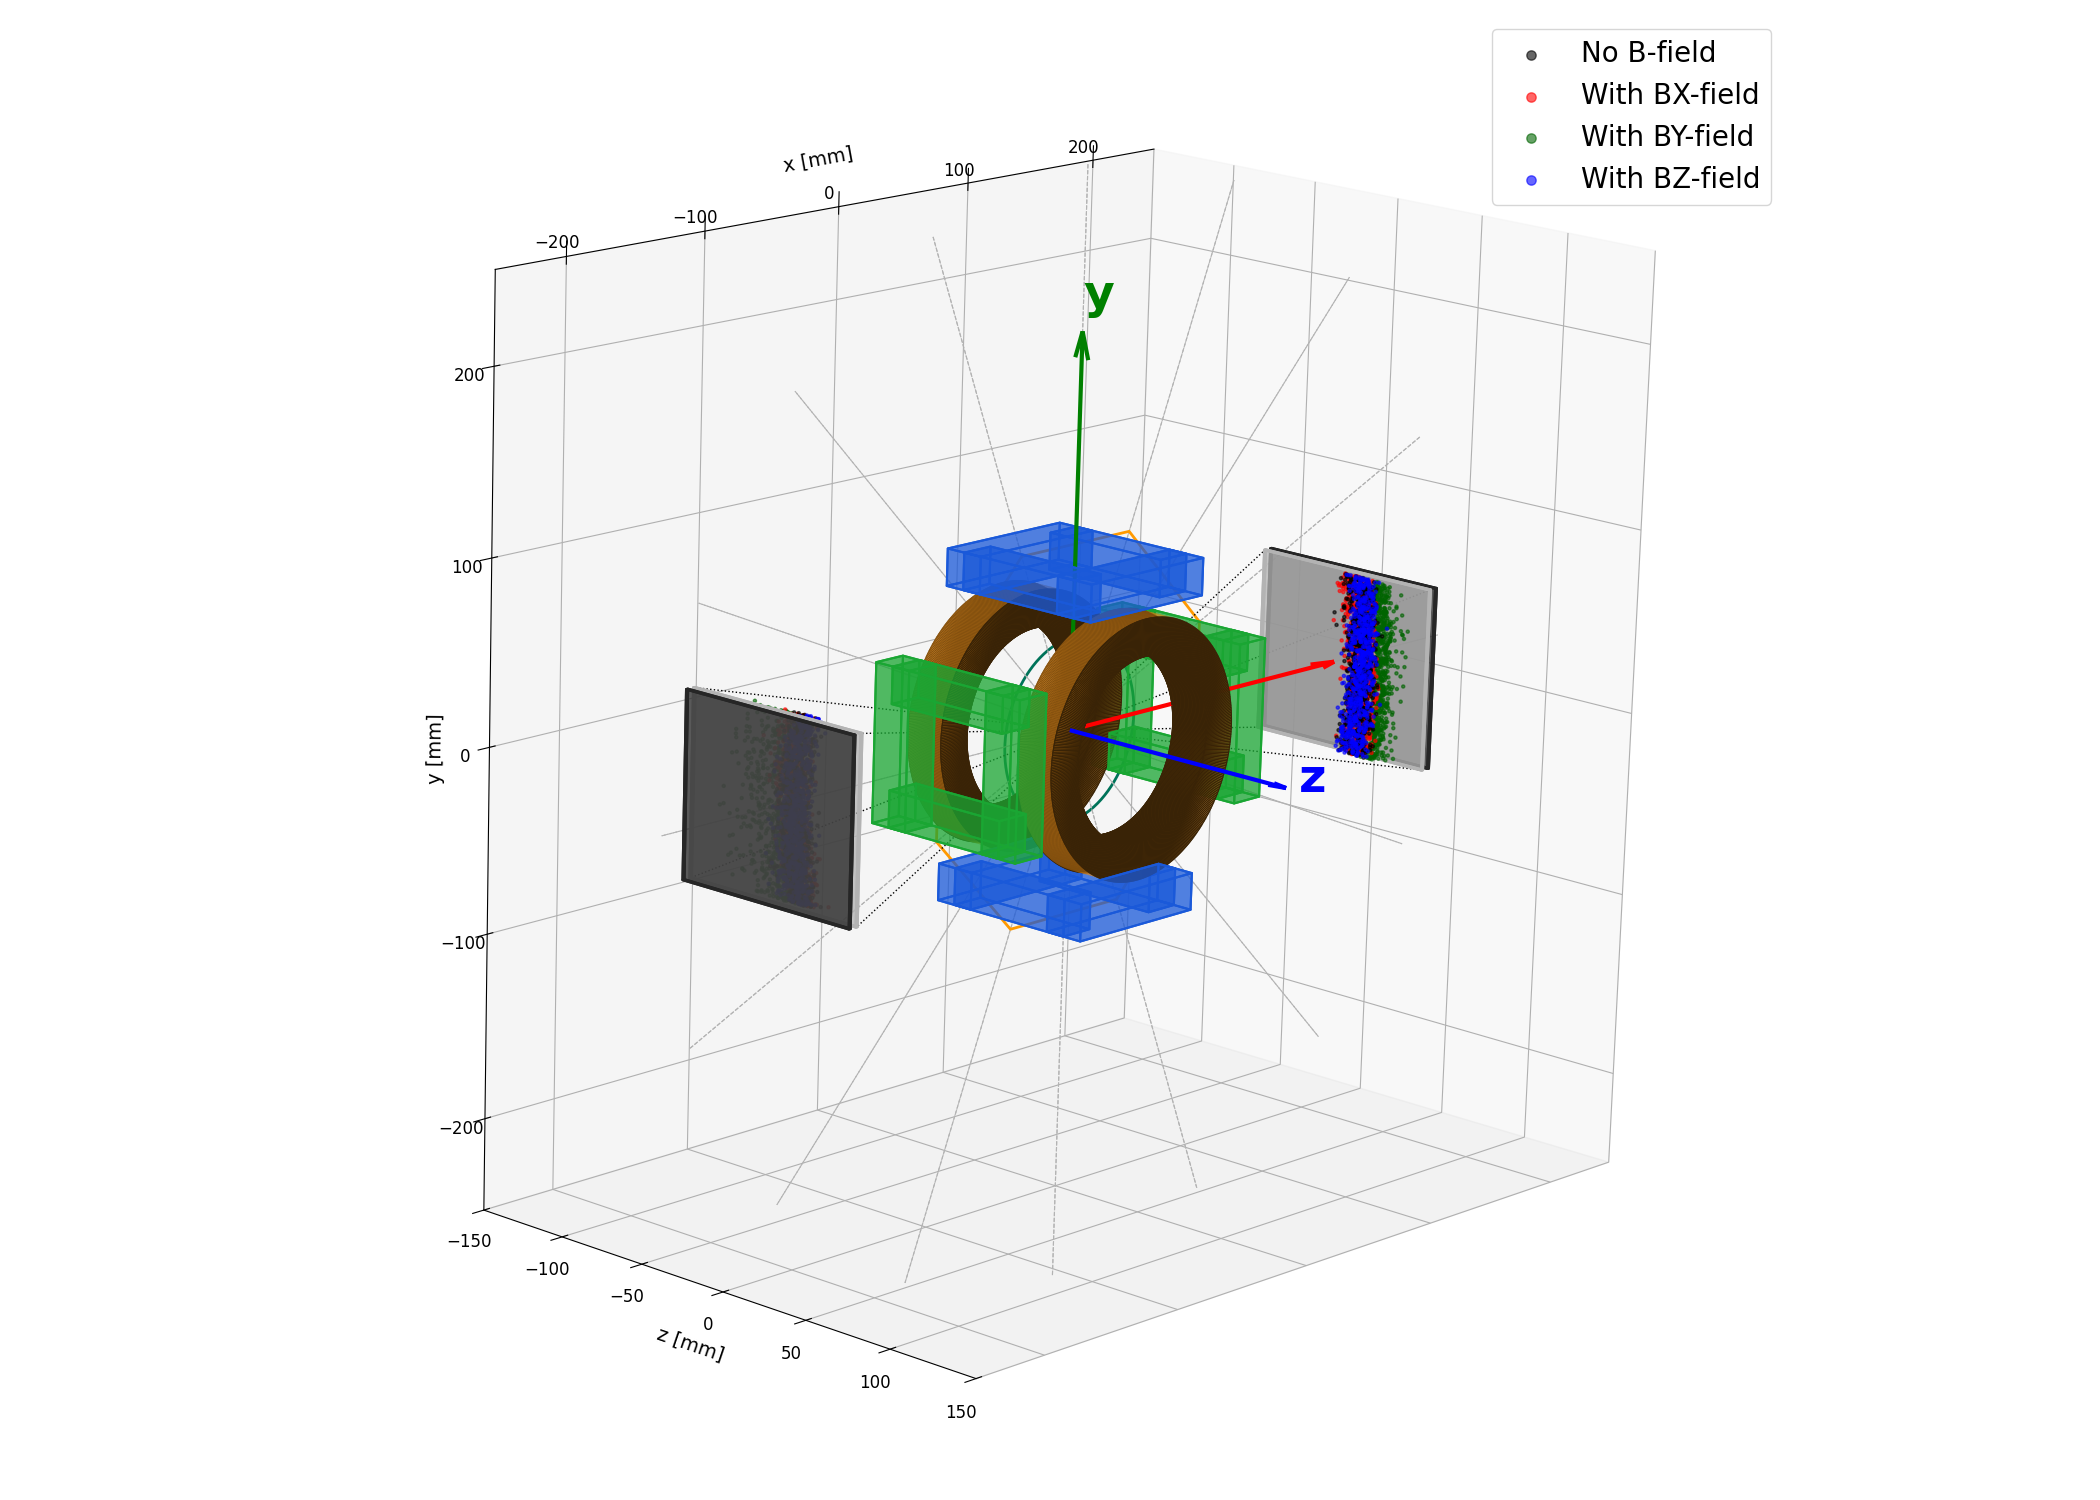

In [44]:



# Set aspect ratio
ax.set_box_aspect([1, 1, 0.7])
ax.legend(fontsize=20, markerscale=3)
plt.tight_layout()
plt.show()

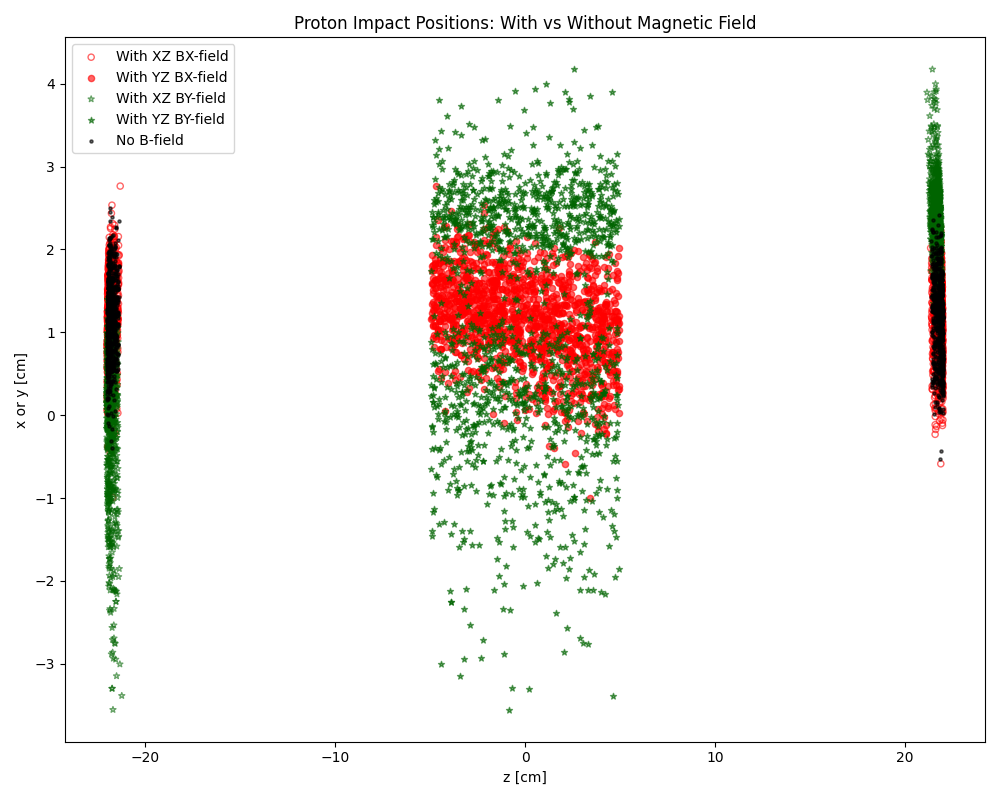

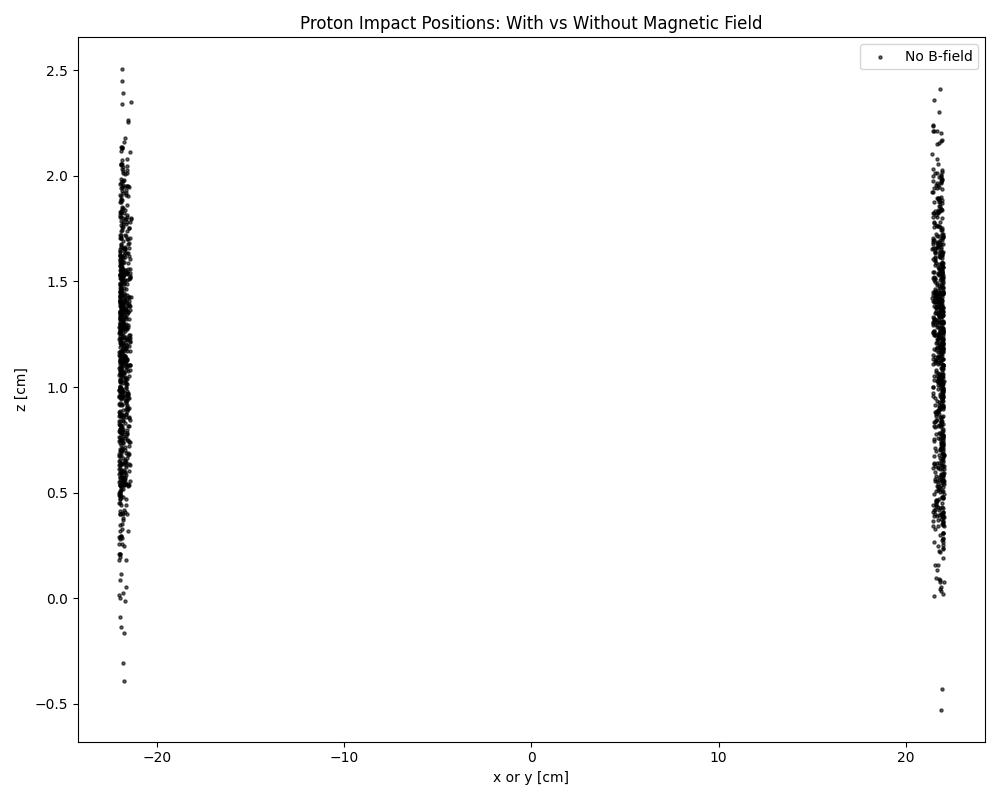

In [45]:
fig, ax = plt.subplots(figsize=(10, 8))


# Draw spheres


# Plot points with magnetic field
ax.scatter(x_withB,  z_withB,  s=20, marker='o', facecolor='none', edgecolor='red', label='With XZ BX-field', alpha=0.6)
ax.scatter(y_withB,  z_withB,  s=20, c='red', marker='o', label='With YZ BX-field', alpha=0.6)
ax.scatter(x_withBY, z_withBY, s=20, marker='*', facecolor='none', edgecolor='darkgreen', label='With XZ BY-field', alpha=0.6)
ax.scatter(y_withBY, z_withBY, s=20, c='darkgreen', marker='*', label='With YZ BY-field', alpha=0.6)

# Plot points without magnetic field
ax.scatter(x_noB,  z_noB, s=5, c='black', label='No B-field', alpha=0.6)

ax.set_xlabel('z [cm]')
ax.set_ylabel('x or y [cm]')
ax.set_title('Proton Impact Positions: With vs Without Magnetic Field')
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))

# Plot points with magnetic field
#ax.scatter(x_withB,  z_withB,  s=15, c='red', label='With X BX-field', alpha=0.6)
#ax.scatter(y_withB,  z_withB,  s=15, c='darkgreen', label='With Y BY-field', alpha=0.6)

# Plot points without magnetic field
ax.scatter(x_noB,  z_noB, s=5, c='black', label='No B-field', alpha=0.6)

ax.set_xlabel('x or y [cm]')
ax.set_ylabel('z [cm]')
ax.set_title('Proton Impact Positions: With vs Without Magnetic Field')
ax.legend()

plt.tight_layout()
plt.show()


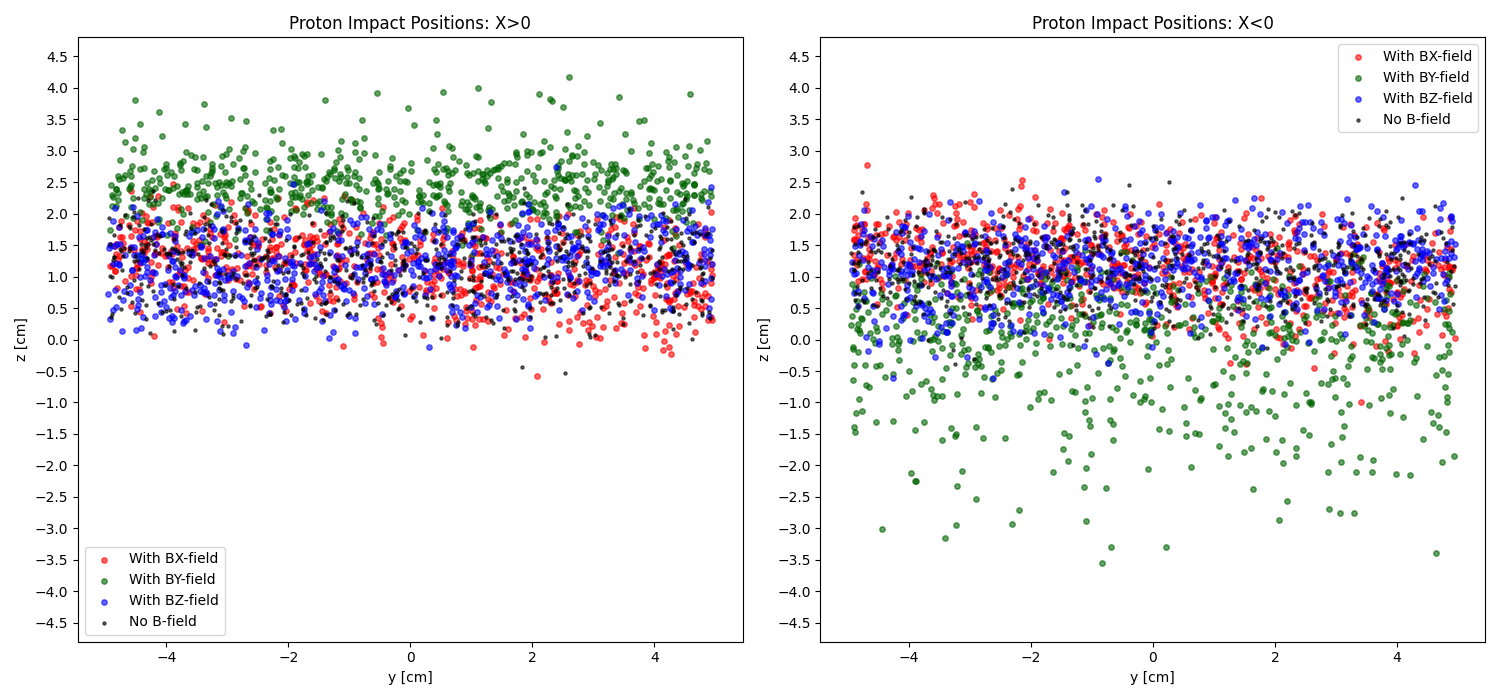

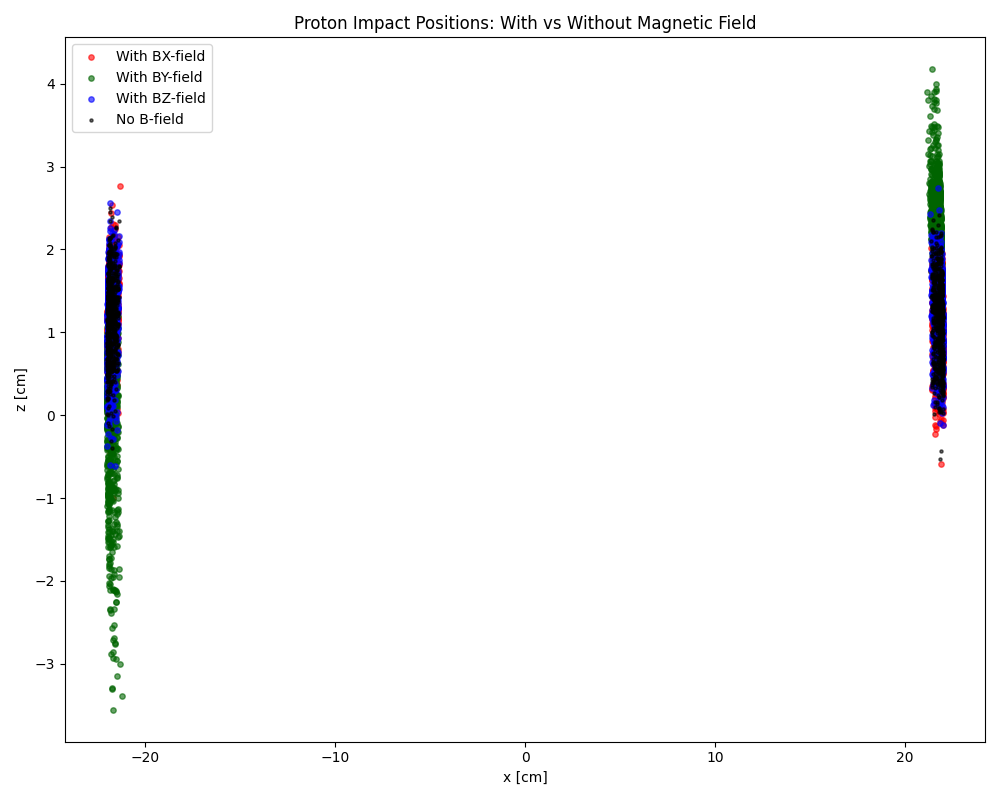

In [46]:
mask_Xp_noB = x_noB >= 0
mask_Xn_noB = x_noB < 0
mask_Xp_B = x_withB >= 0
mask_Xn_B = x_withB < 0
mask_Xp_BY = x_withBY >= 0
mask_Xn_BY = x_withBY < 0
mask_Xp_BZ = x_withBZ >= 0
mask_Xn_BZ = x_withBZ < 0

A_N_Xp_noB = A_N_noB[mask_Xp_noB]
A_N_Xn_noB = A_N_noB[mask_Xn_noB]
A_N_Xp_B = A_N_withB[mask_Xp_B]
A_N_Xn_B = A_N_withB[mask_Xn_B]
A_N_Xp_BY = A_N_withBY[mask_Xp_BY]
A_N_Xn_BY = A_N_withBY[mask_Xn_BY]
A_N_Xp_BZ = A_N_withBZ[mask_Xp_BZ]
A_N_Xn_BZ = A_N_withBZ[mask_Xn_BZ]

fig2, ax2 = plt.subplots(1, 2, figsize=(15, 7))

# Plot points with magnetic field
ax2[0].scatter(y_withB[mask_Xp_B],  z_withB[mask_Xp_B],  s=15, c='red', label='With BX-field', alpha=0.6)
ax2[0].scatter(y_withBY[mask_Xp_BY],  z_withBY[mask_Xp_BY],  s=15, c='darkgreen', label='With BY-field', alpha=0.6)
ax2[0].scatter(y_withBZ[mask_Xp_BZ],  z_withBZ[mask_Xp_BZ],  s=15, c='blue', label='With BZ-field', alpha=0.6)

# Plot points without magnetic field
ax2[0].scatter(y_noB[mask_Xp_noB],  z_noB[mask_Xp_noB], s=5, c='black', label='No B-field', alpha=0.6)

ax2[0].set_xlabel('y [cm]')
ax2[0].set_ylabel('z [cm]')
ax2[0].set_title('Proton Impact Positions: X>0')
ax2[0].legend()

# Plot points with magnetic field
ax2[1].scatter(y_withB[mask_Xn_B],  z_withB[mask_Xn_B],  s=15, c='red', label='With BX-field', alpha=0.6)
ax2[1].scatter(y_withBY[mask_Xn_BY],  z_withBY[mask_Xn_BY],  s=15, c='darkgreen', label='With BY-field', alpha=0.6)
ax2[1].scatter(y_withBZ[mask_Xn_BZ],  z_withBZ[mask_Xn_BZ],  s=15, c='blue', label='With BZ-field', alpha=0.6)

# Plot points without magnetic field
ax2[1].scatter(y_noB[mask_Xn_noB],  z_noB[mask_Xn_noB], s=5, c='black', label='No B-field', alpha=0.6)

ax2[1].set_xlabel('y [cm]')
ax2[1].set_ylabel('z [cm]')
ax2[1].set_title('Proton Impact Positions: X<0')
ax2[1].legend()

ax2[0].set_ylim(-4.8, 4.8)
ax2[1].set_ylim(-4.8, 4.8)
n_tiks = 20
ax2[0].yaxis.set_major_locator(plt.MaxNLocator(n_tiks))
ax2[1].yaxis.set_major_locator(plt.MaxNLocator(n_tiks))

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(10, 8))

# Plot points with magnetic field
ax.scatter(x_withB,  z_withB,  s=15, c='red', label='With BX-field', alpha=0.6)
ax.scatter(x_withBY,  z_withBY,  s=15, c='darkgreen', label='With BY-field', alpha=0.6)
ax.scatter(x_withBZ,  z_withBZ,  s=15, c='blue', label='With BZ-field', alpha=0.6)

# Plot points without magnetic field
ax.scatter(x_noB,  z_noB, s=5, c='black', label='No B-field', alpha=0.6)


ax.set_xlabel('x [cm]')
ax.set_ylabel('z [cm]')
ax.set_title('Proton Impact Positions: With vs Without Magnetic Field')
ax.legend()

plt.tight_layout()
plt.show()

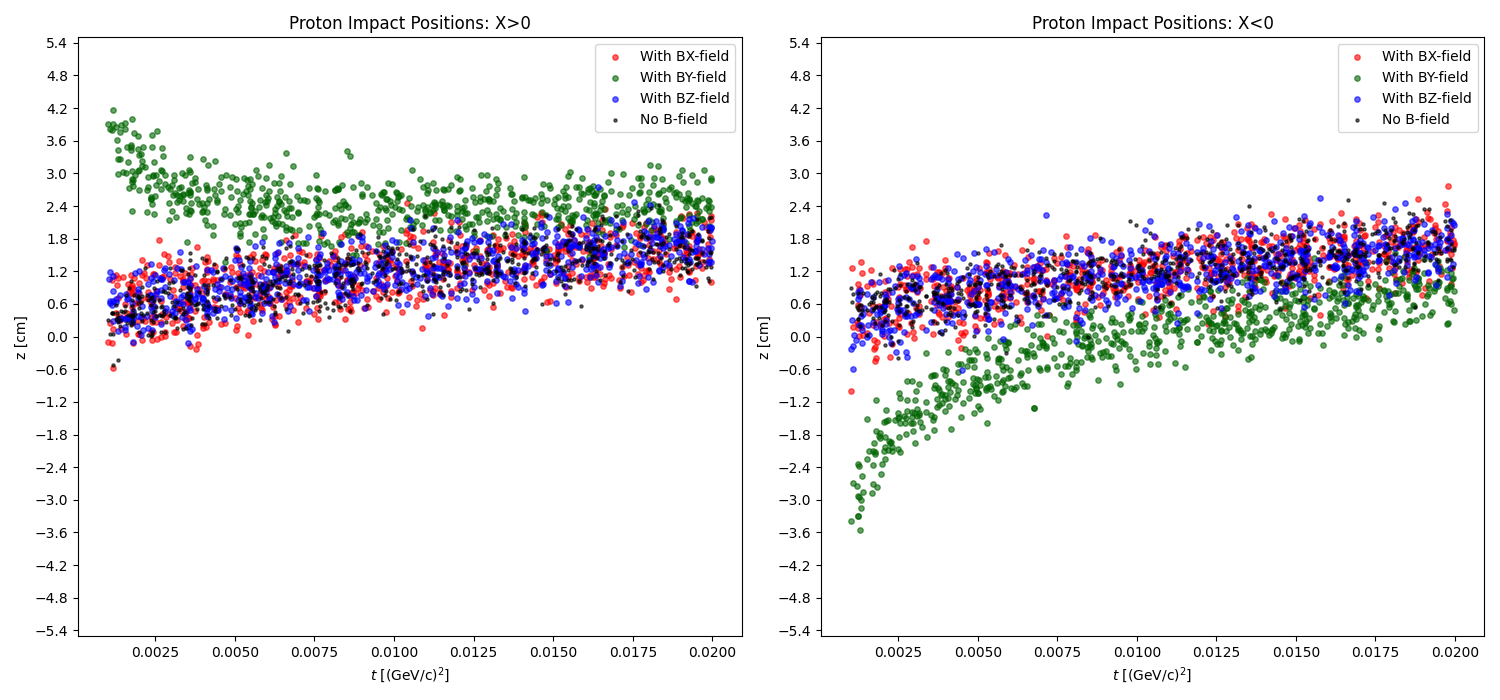

In [47]:
mask_t_Xp_noB = (x_noB >= 0) & (np.abs(y_noB) <= 5)
mask_t_Xn_noB = (x_noB < 0) & (np.abs(y_noB) <= 5)  
mask_t_Xp_B = (x_withB >= 0) & (np.abs(y_withB) <= 5)
mask_t_Xn_B = (x_withB < 0) & (np.abs(y_withB) <= 5)
mask_t_Xp_BY = (x_withBY >= 0) & (np.abs(y_withBY) <= 5)
mask_t_Xn_BY = (x_withBY < 0) & (np.abs(y_withBY) <= 5)
mask_t_Xp_BZ = (x_withBZ >= 0) & (np.abs(y_withBZ) <= 5)
mask_t_Xn_BZ = (x_withBZ < 0) & (np.abs(y_withBZ) <= 5)

fig2, ax2 = plt.subplots(1, 2, figsize=(15, 7))

# Plot points with magnetic field
ax2[0].scatter(t_withBX[mask_t_Xp_B],  z_withB[mask_t_Xp_B],  s=15, c='red', label='With BX-field', alpha=0.6)
ax2[0].scatter(t_withBY[mask_t_Xp_BY],  z_withBY[mask_t_Xp_BY],  s=15, c='darkgreen', label='With BY-field', alpha=0.6)
ax2[0].scatter(t_withBZ[mask_t_Xp_BZ],  z_withBZ[mask_t_Xp_BZ],  s=15, c='blue', label='With BZ-field', alpha=0.6)

# Plot points without magnetic field
ax2[0].scatter(t_noB[mask_t_Xp_noB],  z_noB[mask_t_Xp_noB], s=5, c='black', label='No B-field', alpha=0.6)

ax2[0].set_xlabel(r"$t$ [(GeV/c)$^2$]")
ax2[0].set_ylabel('z [cm]')
ax2[0].set_title('Proton Impact Positions: X>0')
ax2[0].legend()

# Plot points with magnetic field
ax2[1].scatter(t_withBX[mask_t_Xn_B],  z_withB[mask_t_Xn_B],  s=15, c='red', label='With BX-field', alpha=0.6)
ax2[1].scatter(t_withBY[mask_t_Xn_BY],  z_withBY[mask_t_Xn_BY],  s=15, c='darkgreen', label='With BY-field', alpha=0.6)
ax2[1].scatter(t_withBZ[mask_t_Xn_BZ],  z_withBZ[mask_t_Xn_BZ],  s=15, c='blue', label='With BZ-field', alpha=0.6)

# Plot points without magnetic field
ax2[1].scatter(t_noB[mask_t_Xn_noB],  z_noB[mask_t_Xn_noB], s=5, c='black', label='No B-field', alpha=0.6)

ax2[1].set_xlabel(r"$t$ [(GeV/c)$^2$]")
ax2[1].set_ylabel('z [cm]')
ax2[1].set_title('Proton Impact Positions: X<0')
ax2[1].legend()

ax2[0].set_ylim(-5.5, 5.5)
ax2[1].set_ylim(-5.5, 5.5)

n_tiks = 20
ax2[0].yaxis.set_major_locator(plt.MaxNLocator(n_tiks))
ax2[1].yaxis.set_major_locator(plt.MaxNLocator(n_tiks))

plt.tight_layout()
plt.show()




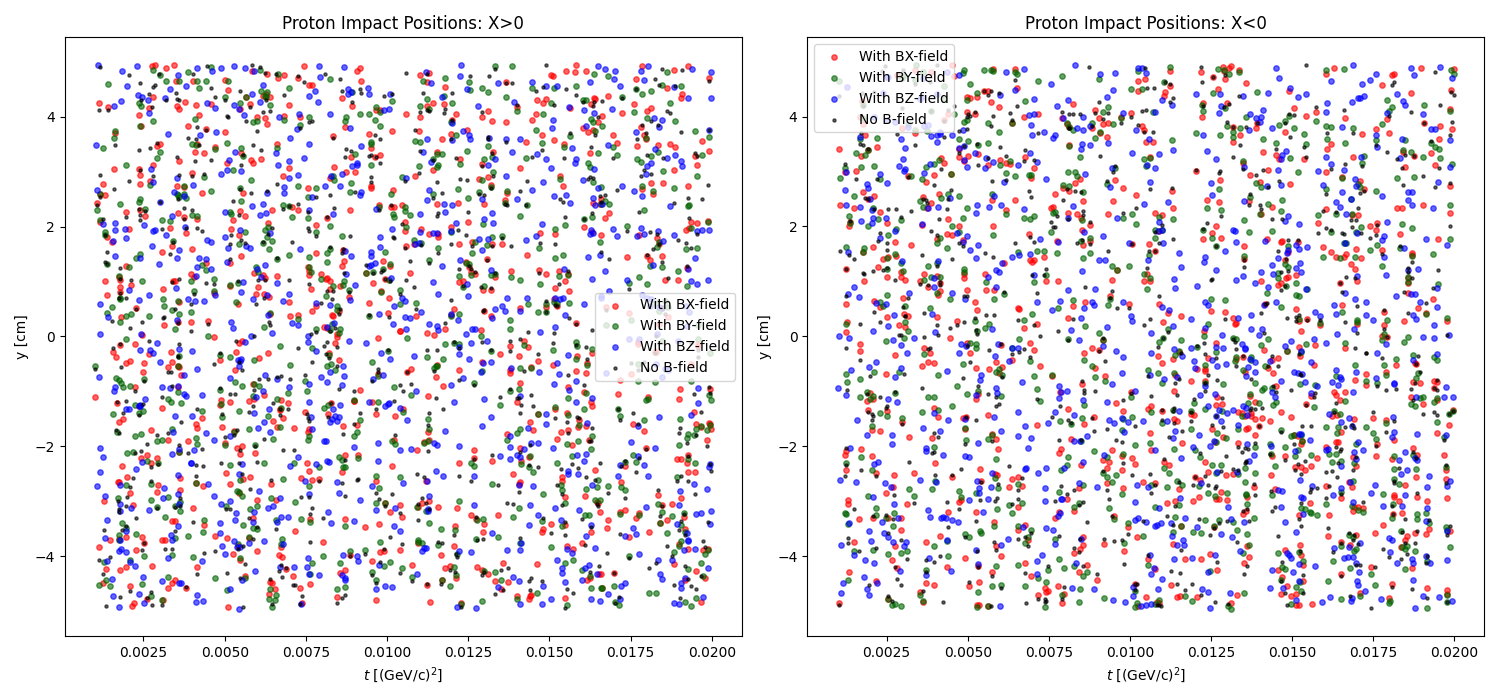

In [48]:
fig2, ax2 = plt.subplots(1, 2, figsize=(15, 7))

# Plot points with magnetic field
ax2[0].scatter(t_withBX[mask_t_Xp_B],  y_withB[mask_t_Xp_B],  s=15, c='red', label='With BX-field', alpha=0.6)
ax2[0].scatter(t_withBY[mask_t_Xp_BY],  y_withBY[mask_t_Xp_BY],  s=15, c='darkgreen', label='With BY-field', alpha=0.6)
ax2[0].scatter(t_withBZ[mask_t_Xp_BZ],  y_withBZ[mask_t_Xp_BZ],  s=15, c='blue', label='With BZ-field', alpha=0.6)

# Plot points without magnetic field
ax2[0].scatter(t_noB[mask_t_Xp_noB],  y_noB[mask_t_Xp_noB], s=5, c='black', label='No B-field', alpha=0.6)

ax2[0].set_xlabel(r"$t$ [(GeV/c)$^2$]")
ax2[0].set_ylabel('y [cm]')
ax2[0].set_title('Proton Impact Positions: X>0')
ax2[0].legend()

# Plot points with magnetic field
ax2[1].scatter(t_withBX[mask_t_Xn_B],  y_withB[mask_t_Xn_B],  s=15, c='red', label='With BX-field', alpha=0.6)
ax2[1].scatter(t_withBY[mask_t_Xn_BY],  y_withBY[mask_t_Xn_BY],  s=15, c='darkgreen', label='With BY-field', alpha=0.6)
ax2[1].scatter(t_withBZ[mask_t_Xn_BZ],  y_withBZ[mask_t_Xn_BZ],  s=15, c='blue', label='With BZ-field', alpha=0.6)

# Plot points without magnetic field
ax2[1].scatter(t_noB[mask_t_Xn_noB],  y_noB[mask_t_Xn_noB], s=5, c='black', label='No B-field', alpha=0.6)

ax2[1].set_xlabel(r"$t$ [(GeV/c)$^2$]")
ax2[1].set_ylabel('y [cm]')
ax2[1].set_title('Proton Impact Positions: X<0')
ax2[1].legend()

plt.tight_layout()
plt.show()

# Digitizing the hit positions onto detector pixels/voxels with a given granularity

In [49]:
def digitize(coord, pitch_cm):
    return pitch_cm * np.round(coord / pitch_cm)


## Choose detector granularity

In [50]:
bin_mm = 0.20          #  mm detector pitch
bin_cm = bin_mm / 10 # convert to cm

In [51]:
xB_d  = digitize(x_withB,  bin_cm)
yB_d  = digitize(y_withB,  bin_cm)
zB_d  = digitize(z_withB,  bin_cm)

xBY_d = digitize(x_withBY, bin_cm)
yBY_d = digitize(y_withBY, bin_cm)
zBY_d = digitize(z_withBY, bin_cm)

xBZ_d = digitize(x_withBZ, bin_cm)
yBZ_d = digitize(y_withBZ, bin_cm)
zBZ_d = digitize(z_withBZ, bin_cm)

x0_d  = digitize(x_noB,    bin_cm)
y0_d  = digitize(y_noB,    bin_cm)
z0_d  = digitize(z_noB,    bin_cm)

## Plot digitized hits (2D projections)

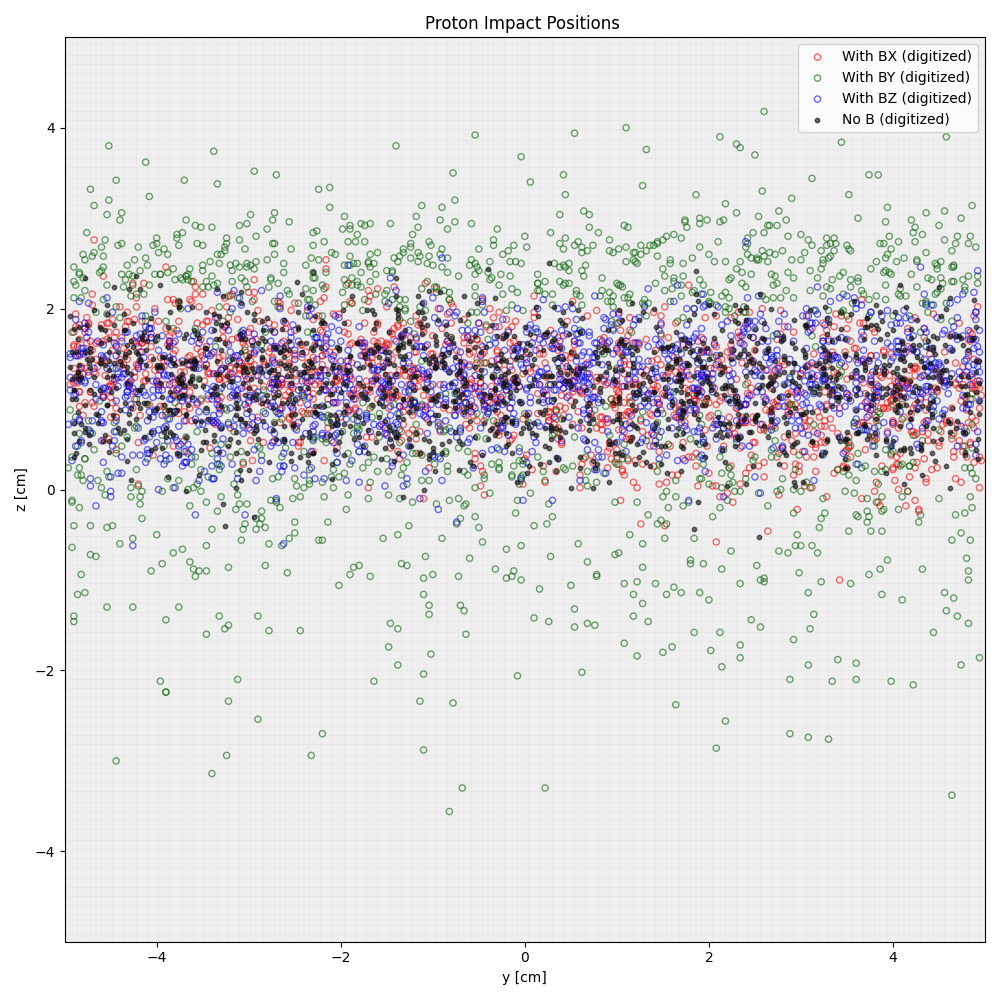

In [52]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(yB_d,  zB_d,  s=20, facecolor='none', edgecolor='red',
           label='With BX (digitized)', alpha=0.6)
ax.scatter(yBY_d,  zBY_d,  s=20, facecolor='none', edgecolor='darkgreen',
           label='With BY (digitized)', alpha=0.6)
ax.scatter(yBZ_d,  zBZ_d,  s=20, facecolor='none', edgecolor='blue',
           label='With BZ (digitized)', alpha=0.6)
ax.scatter(y0_d,  z0_d,  s=10, c='black',
           label='No B (digitized)', alpha=0.6)

ax.set_xlabel('y [cm]')
ax.set_ylabel('z [cm]')
ax.set_title('Proton Impact Positions ')
ax.legend()

# Add pixel mesh
pitch_cm = bin_cm
#xmin, xmax = ax.get_xlim()
#zmin, zmax = ax.get_ylim()
zmin, zmax = -5, 5 
xmin, xmax = -5, 5 
ax.set_ylim(-5, 5)
ax.set_xlim(-5, 5)

for x in np.arange(xmin - pitch_cm/2, xmax + pitch_cm/2, pitch_cm):
    ax.axvline(x, color='gray', lw=0.3, alpha=0.3)

for z in np.arange(zmin - pitch_cm/2, zmax + pitch_cm/2, pitch_cm):
    ax.axhline(z, color='gray', lw=0.3, alpha=0.3)
    
plt.tight_layout()
plt.show()


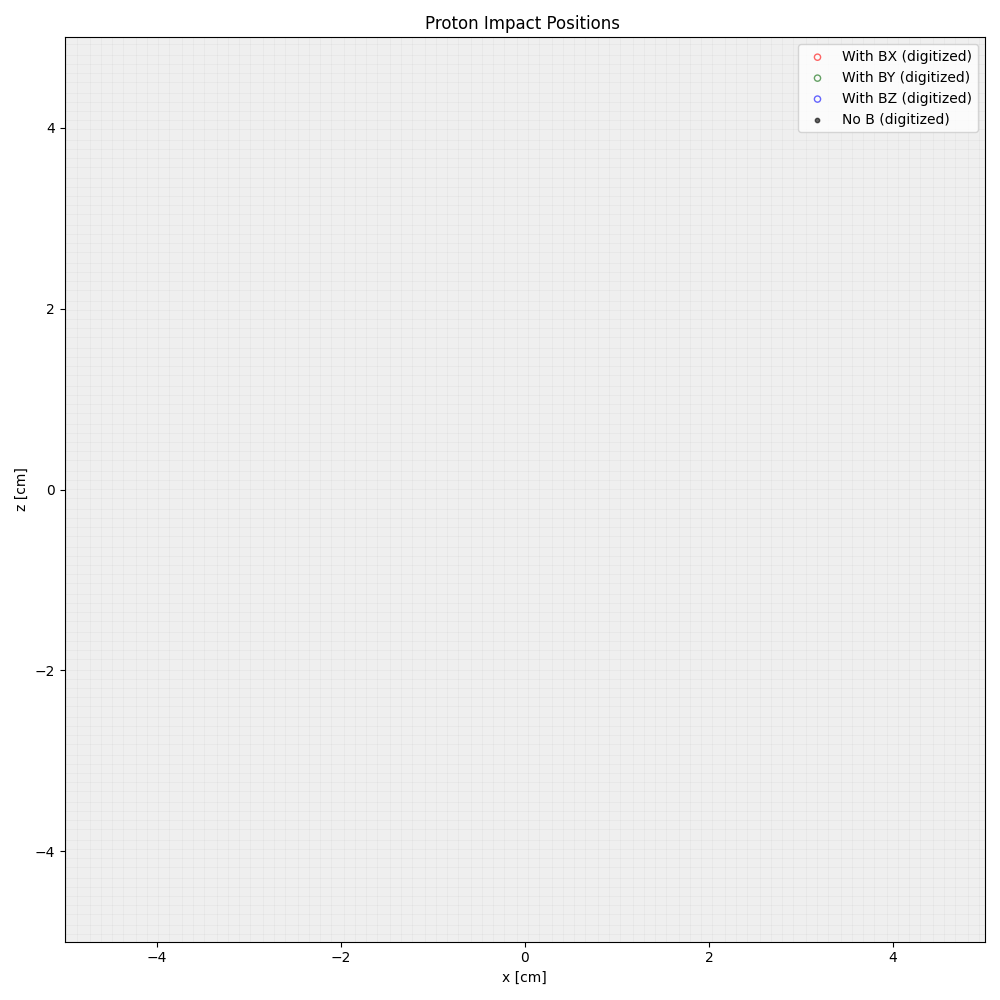

In [53]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(xB_d,  zB_d,  s=20, facecolor='none', edgecolor='red',
           label='With BX (digitized)', alpha=0.6)
ax.scatter(xBY_d,  zBY_d,  s=20, facecolor='none', edgecolor='darkgreen',
           label='With BY (digitized)', alpha=0.6)
ax.scatter(xBZ_d,  zBZ_d,  s=20, facecolor='none', edgecolor='blue',
           label='With BZ (digitized)', alpha=0.6)
ax.scatter(x0_d,  z0_d,  s=10, c='black',
           label='No B (digitized)', alpha=0.6)

ax.set_xlabel('x [cm]')
ax.set_ylabel('z [cm]')
ax.set_title('Proton Impact Positions ')
ax.legend()

# Add pixel mesh
pitch_cm = bin_cm
#xmin, xmax = ax.get_xlim()
#zmin, zmax = ax.get_ylim()
zmin, zmax = -5, 5 
xmin, xmax = -5, 5 
ax.set_ylim(-5, 5)
ax.set_xlim(-5, 5)

for x in np.arange(xmin - pitch_cm/2, xmax + pitch_cm/2, pitch_cm):
    ax.axvline(x, color='gray', lw=0.3, alpha=0.3)

for z in np.arange(zmin - pitch_cm/2, zmax + pitch_cm/2, pitch_cm):
    ax.axhline(z, color='gray', lw=0.3, alpha=0.3)
    
plt.tight_layout()
plt.show()


## Strip detector

In [54]:
# Stripe detector parameters
n_stripes_per_side = 64
total_width_mm = 100  # mm
stripe_pitch_mm = total_width_mm / n_stripes_per_side  # pitch per stripe
stripe_pitch_cm = stripe_pitch_mm / 10  # convert to cm

print(f"Stripe pitch: {stripe_pitch_mm:.4f} mm = {stripe_pitch_cm:.5f} cm")
print(f"Each half (top/bottom) has {n_stripes_per_side} stripes covering {total_width_mm} mm")

# Digitize to stripe numbers (0-511 for each half)
def digitize_stripes(coord_cm, pitch_cm, offset_cm=-5.0):
    """
    Digitize coordinates to stripe numbers.
    coord_cm: coordinate in cm
    pitch_cm: stripe pitch in cm
    offset_cm: offset for start of detector (default -5cm)
    """
    return np.floor((coord_cm - offset_cm) / pitch_cm).astype(int)

# Digitize y-coordinates to stripe numbers (0-511 for each stripe)
yB_stripe  = digitize_stripes(y_withB[mask_Xp_B],  stripe_pitch_cm)
yBY_stripe = digitize_stripes(y_withBY[mask_Xp_BY], stripe_pitch_cm)
yBZ_stripe = digitize_stripes(y_withBZ[mask_Xp_BZ], stripe_pitch_cm)
y0_stripe  = digitize_stripes(y_noB[mask_Xp_noB],  stripe_pitch_cm)

yB_stripe_n  = digitize_stripes(y_withB[mask_Xn_B],  stripe_pitch_cm)
yBY_stripe_n = digitize_stripes(y_withBY[mask_Xn_BY], stripe_pitch_cm)
yBZ_stripe_n = digitize_stripes(y_withBZ[mask_Xn_BZ], stripe_pitch_cm)
y0_stripe_n  = digitize_stripes(y_noB[mask_Xn_noB],  stripe_pitch_cm)



# Determine which half (top or bottom) based on z position
def get_detector_half(z_cm):
    """Return detector half: 0 for bottom (z<0), 1 for top (z>=0)"""
    return (z_cm >= 0).astype(int)

zB_half  = get_detector_half(z_withB[mask_Xp_B])
zBY_half = get_detector_half(z_withBY[mask_Xp_BY])
zBZ_half = get_detector_half(z_withBZ[mask_Xp_BZ])
z0_half  = get_detector_half(z_noB[mask_Xp_noB])

zB_half_n  = get_detector_half(z_withB[mask_Xn_B])
zBY_half_n = get_detector_half(z_withBY[mask_Xn_BY])
zBZ_half_n = get_detector_half(z_withBZ[mask_Xn_BZ])
z0_half_n  = get_detector_half(z_noB[mask_Xn_noB])

Stripe pitch: 1.5625 mm = 0.15625 cm
Each half (top/bottom) has 64 stripes covering 100 mm


/var/folders/6m/3j6qvgsd3lxgmv5gsl7n4sbm0000gp/T/ipykernel_23983/1325378366.py:71: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


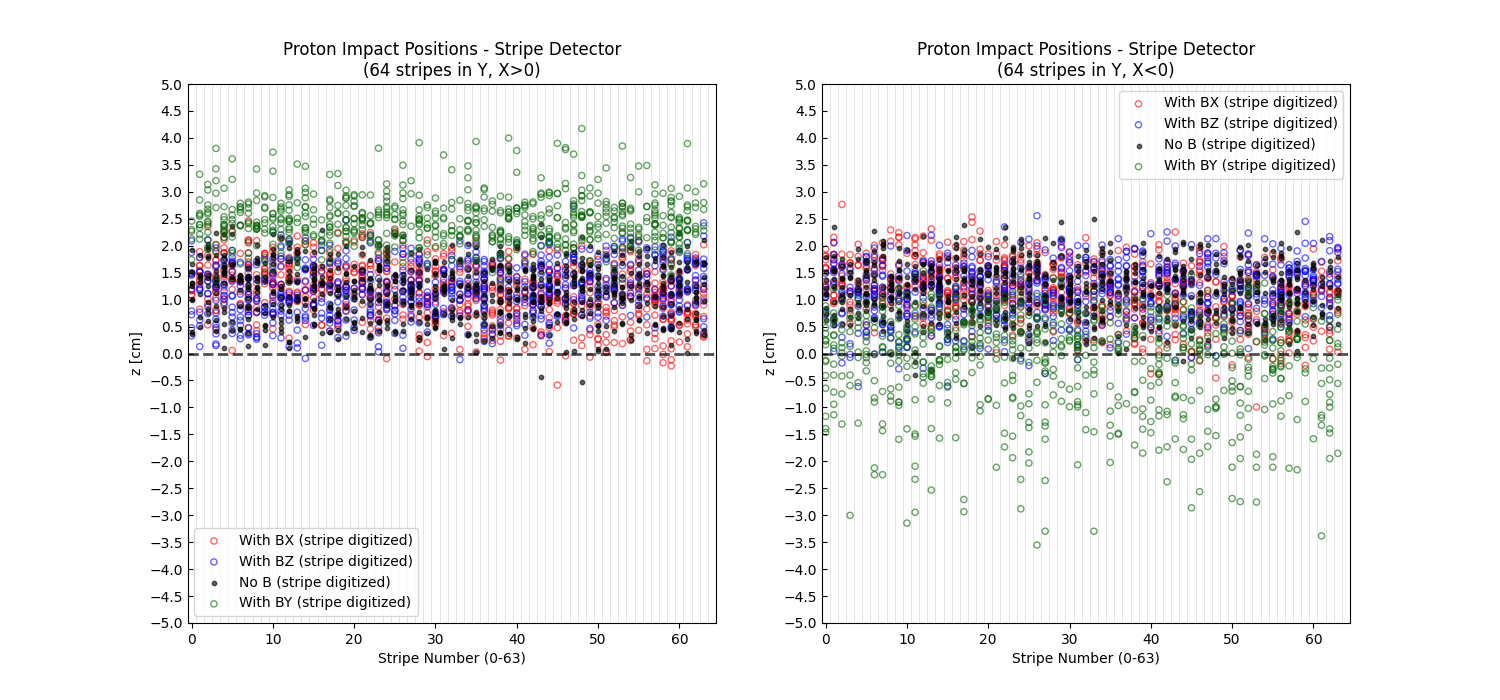


Hit statistics:
BX:  Top=720, Bottom=11
BY:  Top=683, Bottom=0
BZ:  Top=717, Bottom=2
No B: Top=721, Bottom=2


In [55]:
# Visualization
#fig, ax = plt.subplots(figsize=(10, 10))
fig2, ax2 = plt.subplots(1, 2, figsize=(15, 7))

ax2[0].scatter(yB_stripe,  z_withB[mask_Xp_B],  s=20, facecolor='none', edgecolor='red',
           label='With BX (stripe digitized)', alpha=0.6)
ax2[0].scatter(yBZ_stripe, z_withBZ[mask_Xp_BZ], s=20, facecolor='none', edgecolor='blue',
           label='With BZ (stripe digitized)', alpha=0.6)
ax2[0].scatter(y0_stripe,  z_noB[mask_Xp_noB],  s=10, c='black',
           label='No B (stripe digitized)', alpha=0.6)
ax2[0].scatter(yBY_stripe, z_withBY[mask_Xp_BY], s=20, facecolor='none', edgecolor='darkgreen',
           label='With BY (stripe digitized)', alpha=0.6)

ax2[0].set_xlabel(f'Stripe Number (0-{n_stripes_per_side-1})')
ax2[0].set_ylabel('z [cm]')
ax2[0].set_title(f'Proton Impact Positions - Stripe Detector\n({n_stripes_per_side} stripes in Y, X>0)')
ax2[0].legend()

ax2[0].set_ylim(-5, 5)
ax2[0].set_xlim(-0.5, n_stripes_per_side+0.5)

# Mark the Z=0 split line (horizontal)
ax2[0].axhline(0, color='black', lw=2, alpha=0.7, linestyle='--', label='Detector split (Z=0)')

# Add vertical lines for stripe boundaries (every stripe)
for stripe in range(0, n_stripes_per_side+1, 1):
    ax2[0].axvline(stripe-0.5, color='gray', lw=0.5, alpha=0.3)

# Add labels for top/bottom halves
ax2[0].text(256, 4, 'Top Half (Z>0)', ha='center', fontsize=12, 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax2[0].text(256, -4, 'Bottom Half (Z<0)', ha='center', fontsize=12,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# Second detector half (X<0)
ax2[1].scatter(yB_stripe_n,  z_withB[mask_Xn_B],  s=20, facecolor='none', edgecolor='red',
           label='With BX (stripe digitized)', alpha=0.6)
ax2[1].scatter(yBZ_stripe_n, z_withBZ[mask_Xn_BZ], s=20, facecolor='none', edgecolor='blue',
           label='With BZ (stripe digitized)', alpha=0.6)
ax2[1].scatter(y0_stripe_n,  z_noB[mask_Xn_noB],  s=10, c='black',
           label='No B (stripe digitized)', alpha=0.6)
ax2[1].scatter(yBY_stripe_n, z_withBY[mask_Xn_BY], s=20, facecolor='none', edgecolor='darkgreen',
           label='With BY (stripe digitized)', alpha=0.6)

ax2[1].set_xlabel(f'Stripe Number (0-{n_stripes_per_side-1})')
ax2[1].set_ylabel('z [cm]')
ax2[1].set_title(f'Proton Impact Positions - Stripe Detector\n({n_stripes_per_side} stripes in Y, X<0)')
ax2[1].legend()

ax2[1].set_ylim(-5, 5)
ax2[1].set_xlim(-0.5, n_stripes_per_side+0.5)
# Mark the Z=0 split line (horizontal)
ax2[1].axhline(0, color='black', lw=2, alpha=0.7, linestyle='--', label='Detector split (Z=0)')

# Add vertical lines for stripe boundaries (every stripe)
for stripe in range(0, n_stripes_per_side+1, 1):
    ax2[1].axvline(stripe-0.5, color='gray', lw=0.5, alpha=0.3)

# Add labels for top/bottom halves
ax2[1].text(256, 4, 'Top Half (Z>0)', ha='center', fontsize=12,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax2[1].text(256, -4, 'Bottom Half (Z<0)', ha='center', fontsize=12,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

n_tiks = 20
ax2[0].tick_params(axis='y', which='both', direction='in')
ax2[0].yaxis.set_major_locator(plt.MaxNLocator(n_tiks))
ax2[1].tick_params(axis='y', which='both', direction='in')
ax2[1].yaxis.set_major_locator(plt.MaxNLocator(n_tiks))

plt.tight_layout()
plt.show()

# Print some statistics
print(f"\nHit statistics:")
print(f"BX:  Top={np.sum(zB_half==1)}, Bottom={np.sum(zB_half==0)}")
print(f"BY:  Top={np.sum(zBY_half==1)}, Bottom={np.sum(zBY_half==0)}")
print(f"BZ:  Top={np.sum(zBZ_half==1)}, Bottom={np.sum(zBZ_half==0)}")
print(f"No B: Top={np.sum(z0_half==1)}, Bottom={np.sum(z0_half==0)}")

/var/folders/6m/3j6qvgsd3lxgmv5gsl7n4sbm0000gp/T/ipykernel_23983/2125186719.py:117: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


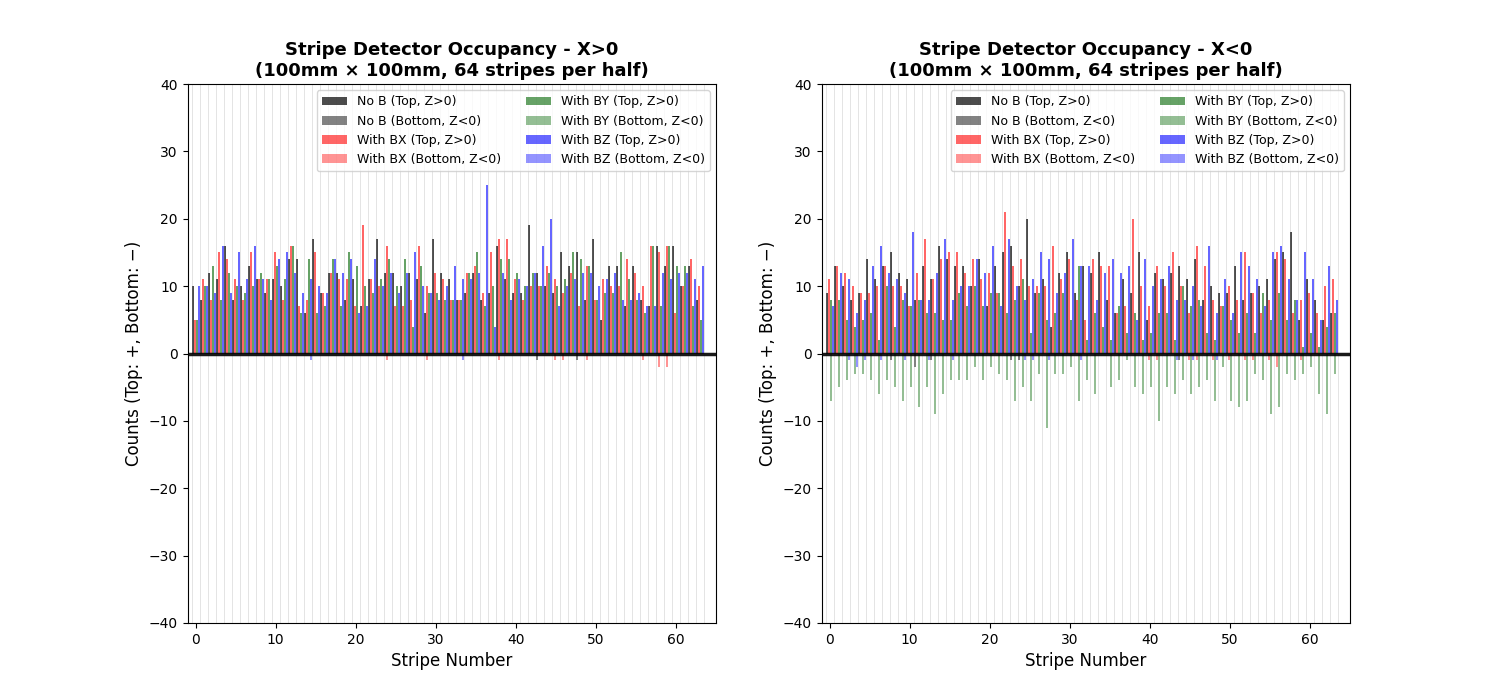


Stripe occupancy summary:
Config     Top hits     Bottom hits  Total      Asymmetry 
------------------------------------------------------------
No B       721          2            723        +0.994
BX         720          11           731        +0.970
BY         683          0            683        +1.000
BZ         717          2            719        +0.994


In [56]:
# Count hits per stripe for each half
def count_stripe_hits(stripe_nums, A_N, z_half, n_stripes=n_stripes_per_side, AN_flag=False):
    """
    Count hits per stripe, separated by detector half.
    Returns counts for bottom (negative) and top (positive).
    """
    top_counts = np.zeros(n_stripes)
    bottom_counts = np.zeros(n_stripes)
    
    for stripe, half in zip(stripe_nums, z_half):
        if 0 <= stripe < n_stripes:
            if half == 1:  # top
                if AN_flag:
                    top_counts[stripe] += 1*A_N[stripe]
                else:
                    top_counts[stripe] += 1
            else:  # bottom
                if AN_flag:
                    bottom_counts[stripe] += 1*A_N[stripe]
                else:
                    bottom_counts[stripe] += 1
    return bottom_counts, top_counts

# Calculate counts for each configuration
bottom_B, top_B = count_stripe_hits(yB_stripe, A_N_Xp_B, zB_half)
bottom_BY, top_BY = count_stripe_hits(yBY_stripe, A_N_Xp_BY, zBY_half)
bottom_BZ, top_BZ = count_stripe_hits(yBZ_stripe, A_N_Xp_BZ, zBZ_half)
bottom_0, top_0 = count_stripe_hits(y0_stripe, A_N_Xp_noB, z0_half)

bottom_B_n, top_B_n = count_stripe_hits(yB_stripe_n, A_N_Xn_B, zB_half_n)
bottom_BY_n, top_BY_n = count_stripe_hits(yBY_stripe_n, A_N_Xn_BY, zBY_half_n)
bottom_BZ_n, top_BZ_n = count_stripe_hits(yBZ_stripe_n, A_N_Xn_BZ, zBZ_half_n)
bottom_0_n, top_0_n = count_stripe_hits(y0_stripe_n, A_N_Xn_noB, z0_half_n)

# Create stripe array
stripes = np.arange(-0.5, n_stripes_per_side-0.5)

# Double plot with all configurations as bars
#fig2, ax2 = plt.subplots(figsize=(14, 8))
fig2, ax2 = plt.subplots(1, 2, figsize=(15, 7))

# Bar width and positions
bar_width = 0.25
positions = [stripes + 0.5*bar_width, stripes + 1.5*bar_width, 
             stripes + 2.5*bar_width, stripes + 3.5*bar_width]

configs = [
    (bottom_0, top_0,  'No B', 'black', 0.7),
    (bottom_B, top_B, 'With BX', 'red', 0.6),
    (bottom_BY, top_BY, 'With BY', 'darkgreen', 0.6),
    (bottom_BZ, top_BZ, 'With BZ', 'blue', 0.6),
]

# Plot each configuration
for pos, (bottom, top, label, color, alpha) in zip(positions, configs):
    # Top half (positive)
    ax2[0].bar(pos, top, width=bar_width, color=color, alpha=alpha, 
           label=f'{label} (Top, Z>0)')
    # Bottom half (negative)
    ax2[0].bar(pos, -bottom, width=bar_width, color=color, alpha=alpha*0.7, 
           label=f'{label} (Bottom, Z<0)')

# Add zero line to show detector split
ax2[0].axhline(0, color='black', lw=2.5, linestyle='-', alpha=0.9, zorder=10)
ax2[0].text(256, 0, ' Detector Split (Z=0) ', ha='center', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', linewidth=1.5),
        fontsize=10, fontweight='bold', zorder=11)

ax2[0].set_xlabel('Stripe Number', fontsize=12)
ax2[0].set_ylabel('Counts (Top: +, Bottom: −)', fontsize=12)
ax2[0].set_title(f'Stripe Detector Occupancy - X>0\n(100mm × 100mm, {n_stripes_per_side} stripes per half)', 
             fontsize=13, fontweight='bold')
ax2[0].set_ylim(-40, 40)
ax2[0].set_xlim(-1, n_stripes_per_side + 1)
ax2[0].legend( fontsize=9, ncol=2)
#ax.grid(True, alpha=0.3, axis='y')



configs_n = [
    (bottom_0_n, top_0_n, 'No B', 'black', 0.7),
    (bottom_B_n, top_B_n, 'With BX', 'red', 0.6),
    (bottom_BY_n, top_BY_n, 'With BY', 'darkgreen', 0.6),
    (bottom_BZ_n, top_BZ_n, 'With BZ', 'blue', 0.6),
]

# Plot each configuration
for pos, (bottom, top, label, color, alpha) in zip(positions, configs_n):
    # Top half (positive)
    ax2[1].bar(pos, top, width=bar_width, color=color, alpha=alpha, 
           label=f'{label} (Top, Z>0)')
    # Bottom half (negative)
    ax2[1].bar(pos, -bottom, width=bar_width, color=color, alpha=alpha*0.7, 
           label=f'{label} (Bottom, Z<0)')

# Add zero line to show detector split
ax2[1].axhline(0, color='black', lw=2.5, linestyle='-', alpha=0.9, zorder=10)
ax2[1].text(256, 0, ' Detector Split (Z=0) ', ha='center', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', linewidth=1.5),
        fontsize=10, fontweight='bold', zorder=11)

ax2[1].set_xlabel('Stripe Number', fontsize=12)
ax2[1].set_ylabel('Counts (Top: +, Bottom: −)', fontsize=12)
ax2[1].set_title(f'Stripe Detector Occupancy - X<0\n(100mm × 100mm, {n_stripes_per_side} stripes per half)', 
             fontsize=13, fontweight='bold')
ax2[1].set_ylim(-40, 40)
ax2[1].set_xlim(-1, n_stripes_per_side + 1)
ax2[1].legend( fontsize=9, ncol=2)
#ax.grid(True, alpha=0.3, axis='y')

# Add vertical lines for stripe boundaries (every stripe)
for stripe in range(0, n_stripes_per_side+1, 1):
    ax2[0].axvline(stripe-0.5, color='gray', lw=0.5, alpha=0.3)
    ax2[1].axvline(stripe-0.5, color='gray', lw=0.5, alpha=0.3)


plt.tight_layout()
plt.show()

# Print summary statistics
print("\nStripe occupancy summary:")
print(f"{'Config':<10} {'Top hits':<12} {'Bottom hits':<12} {'Total':<10} {'Asymmetry':<10}")
print("-" * 60)
for title, (bottom, top) in [('No B', (bottom_0, top_0)),
                              ('BX', (bottom_B, top_B)), 
                              ('BY', (bottom_BY, top_BY)),
                              ('BZ', (bottom_BZ, top_BZ))]:
    top_sum = np.sum(top)
    bottom_sum = np.sum(bottom)
    total = top_sum + bottom_sum
    asymmetry = (top_sum - bottom_sum) / total if total > 0 else 0
    print(f"{title:<10} {int(top_sum):<12} {int(bottom_sum):<12} {int(total):<10} {asymmetry:>+.3f}")

## True detector-style binning (occupancy map)

In [57]:
xbins = np.arange(xB_d.min(), xB_d.max() + bin_cm, bin_cm)
zbins = np.arange(zB_d.min(), zB_d.max() + bin_cm, bin_cm)

H, xedges, zedges = np.histogram2d(xB_d, zB_d, bins=[xbins, zbins])

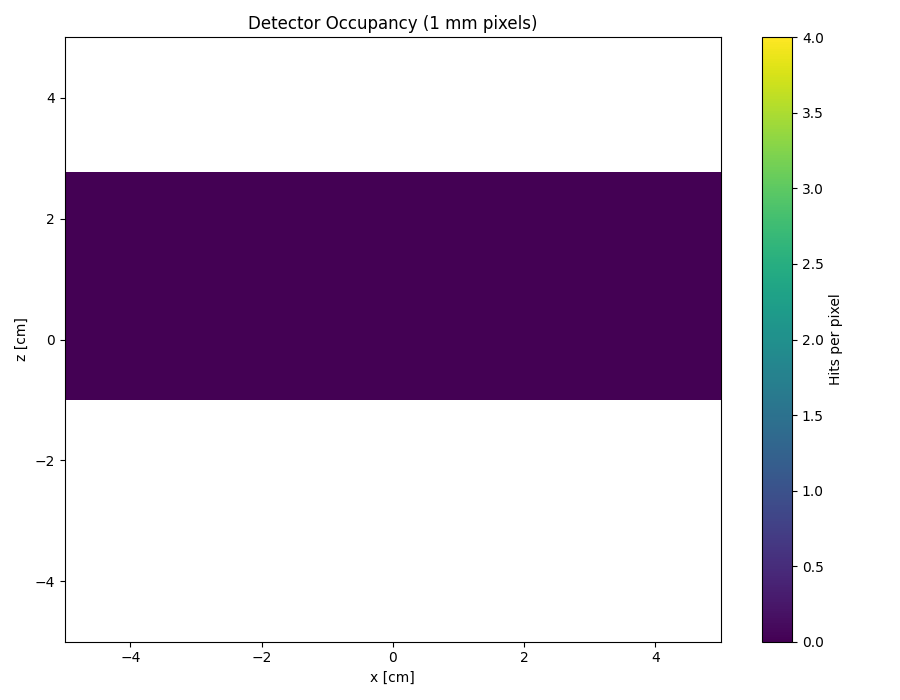

In [58]:
plt.figure(figsize=(9, 7))
plt.imshow(H.T, origin='lower', aspect='auto',
           extent=[xbins[0], xbins[-1], zbins[0], zbins[-1]])
plt.colorbar(label='Hits per pixel')
plt.xlabel('x [cm]')
plt.ylabel('z [cm]')
plt.ylim(-5, 5)
plt.xlim(-5, 5)
plt.title('Detector Occupancy (1 mm pixels)')
plt.tight_layout()
plt.show()

## Full 3D voxelization (XYZ detector)

In [59]:
#bins_x = np.arange(xB_d.min(), xB_d.max()+bin_cm, bin_cm)
#bins_y = np.arange(yB_d.min(), yB_d.max()+bin_cm, bin_cm)
#bins_z = np.arange(zB_d.min(), zB_d.max()+bin_cm, bin_cm)
#
#H3D, edges = np.histogramdd(
#    np.vstack([xB_d, yB_d, zB_d]).T,
#    bins=[bins_x, bins_y, bins_z]
#)

## Optional: add resolution smearing

In [60]:
#sigma = 0.03  # 300 microns
#xB_d += np.random.normal(0, sigma, size=len(xB_d))
#zB_d += np.random.normal(0, sigma, size=len(zB_d))